# 17 — Final Model Training and Artifact Preparation

This notebook finalizes the selected fraud detection model workflow and prepares the project for inference and FastAPI integration. The focus is production readiness: clear paths, final artifact locations, and a clean setup for training and saving the validated model in later phases.


## Purpose

This notebook exists to prepare the final training and artifact-saving workflow for the fraud detection system.

It will eventually be responsible for:

- Training the final selected fraud detection model
- Reusing the final decision policy from previous notebooks
- Saving model artifacts needed for inference
- Saving feature columns, metrics, metadata, and decision policy
- Preparing the project for the next inference/API stage

This notebook should not repeat full EDA, full model comparison, or threshold tuning. Those tasks were completed earlier in the project. Notebook 17 is focused on turning the validated modeling decisions into reusable production-style artifacts.


## Previous Notebook Context

The project workflow leading into this notebook is:

- `13_model_training.ipynb` trained candidate models.
- `14_model_evaluation.ipynb` evaluated model performance and confirmed the strongest model choice.
- `15_threshold_tuning.ipynb` selected suitable fraud probability thresholds using validation/OOF predictions and holdout confirmation.
- `16_decision_logic.ipynb` converted model fraud probabilities into `APPROVE`, `REVIEW`, and `BLOCK` decisions.
- `17_final_model_training.ipynb` now prepares the final validated model training and artifact-saving workflow.

The difference between notebook 13 and notebook 17 is important. Notebook 13 is for experimentation and candidate model training. Notebook 17 is for final validated model training and artifact preparation for inference/API use. In other words, notebook 13 helps decide what works; notebook 17 prepares the final version for reuse by downstream code.


## Imports

This section imports the libraries needed for the notebook setup and the later final-training workflow. The imports are intentionally placed up front so the notebook can train the final model, compute metrics, and save artifacts without changing the environment configuration.


In [73]:
import json
from datetime import datetime
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## Path Configuration

This section defines all important input and output paths with `pathlib.Path`. The project root logic works whether the notebook is run from the repository root or from inside the `notebooks/` folder.

This setup step only configures paths. It does not load the dataset, train a model, evaluate a model, or save final model artifacts.


In [74]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables" / "17_final_model_training"
FIGURES_DIR = REPORTS_DIR / "figures" / "17_final_model_training"

# Leakage-safe final training starts from the cleaned dataset and recreates the
# approved deterministic features inside this notebook.
CLEANED_DATASET_PATH = DATA_INTERIM_DIR / "creditcard_cleaned.csv"
DECISION_POLICY_PATH = ARTIFACTS_DIR / "decision_policy.json"

FINAL_MODEL_PATH = ARTIFACTS_DIR / "final_validated_fraud_model.joblib"
FINAL_FEATURE_COLUMNS_PATH = ARTIFACTS_DIR / "final_feature_columns.json"
FINAL_MODEL_METADATA_PATH = ARTIFACTS_DIR / "final_model_metadata.json"
FINAL_MODEL_METRICS_PATH = ARTIFACTS_DIR / "final_model_metrics.json"
FINAL_DECISION_POLICY_PATH = ARTIFACTS_DIR / "final_decision_policy.json"

# Set to True only when creating a deployment-ready model
# after all validation and evaluation steps are complete.
RUN_PRODUCTION_REFIT = True


## Output Folder Creation

This section creates the folders that later phases will use for artifacts, tables, and figures. Creating them now makes the notebook environment easy to verify before any final model training begins.


In [75]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

configured_paths = {
    "Project root": PROJECT_ROOT,
    "Interim data directory": DATA_INTERIM_DIR,
    "Processed data directory": DATA_PROCESSED_DIR,
    "Artifacts directory": ARTIFACTS_DIR,
    "Tables output directory": TABLES_DIR,
    "Figures output directory": FIGURES_DIR,
    "Cleaned dataset path": CLEANED_DATASET_PATH,
    "Decision policy path": DECISION_POLICY_PATH,
    "Final model artifact path": FINAL_MODEL_PATH,
    "Run production refit": RUN_PRODUCTION_REFIT,
}

print("Configured notebook paths:")
for label, path in configured_paths.items():
    print(f"- {label}: {path}")


Configured notebook paths:
- Project root: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection
- Interim data directory: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/data/interim
- Processed data directory: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/data/processed
- Artifacts directory: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts
- Tables output directory: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training
- Figures output directory: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/17_final_model_training
- Cleaned dataset path: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/data/interim/creditcard_cleaned.csv
- Decision policy path: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/decision_policy.json
- Final model artifact path: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/final_validated_fraud_model.joblib
- Run production refit: True


## Environment Check

Before moving into dataset loading and final model training, confirm the setup questions below:

- Do I know the input dataset path?
- Do I know where final model artifacts will be saved?
- Do I know where reports and tables will be saved?
- Do I understand the difference between notebook 13 and notebook 17?
- Did the required output folders get created successfully?

At this point the notebook environment is configured, but no data has been loaded, no model has been trained, no evaluation has been run, and no final model artifacts have been saved yet.


## Feature Lineage and Leakage Safety

Final training in this notebook starts from the cleaned dataset rather than from a pre-selected feature sheet.

- The input file is `data/interim/creditcard_cleaned.csv`.
- Approved engineered features are recreated deterministically inside this notebook using only raw feature columns.
- No target-based feature selection, correlation screening, or feature discovery is performed in Notebook 17.
- The approved feature list is treated as a fixed modeling decision carried forward from earlier review.
- The train/test split happens before model fitting.
- Final evaluation is performed on the unseen holdout test split.


### Load Dataset

The final model-ready dataset should come from the processed data directory configured earlier in this notebook. This section checks that the path exists before loading anything. If the file is missing, the notebook shows the available processed CSV files and stops with a clear error so the dataset path can be corrected safely.


In [76]:
if not CLEANED_DATASET_PATH.exists():
    available_files = list(DATA_INTERIM_DIR.glob("*.csv"))
    print("Available interim CSV files:")
    for file in available_files:
        print("-", file.name)
    raise FileNotFoundError(f"Cleaned dataset not found: {CLEANED_DATASET_PATH}")

df = pd.read_csv(CLEANED_DATASET_PATH)


### Dataset Shape

This section confirms the size of the final training dataset and shows the first few rows. It helps verify that the notebook is pointing to the expected processed file before any final training logic is added.


In [77]:
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
display(df.head())


Dataset shape: 283726 rows x 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000000,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.620000,0
1,0.000000,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000,0
2,1.000000,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660000,0
3,1.000000,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000,0
4,2.000000,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.990000,0


### Identify Target Column

The fraud target is expected to be stored in the `Class` column.

- `Class = 1` means a fraud transaction.
- `Class = 0` means a normal or non-fraud transaction.

This check keeps the notebook explicit about the prediction target and avoids silent mistakes if the processed dataset schema changes.


In [78]:
TARGET_COL = "Class"
APPROVED_FEATURES = [
    "V14_V12_interaction",
    "V14",
    "V17_V16_interaction",
    "V12",
    "V17",
    "V10",
    "V4",
    "V16",
    "V3",
    "V11",
    "V7",
    "V18",
    "log_amount",
]

if TARGET_COL not in df.columns:
    print("Available columns:")
    print(df.columns.tolist())
    raise ValueError(f"Target column '{TARGET_COL}' not found in dataset.")

# Recreate the approved deterministic engineered features directly from cleaned data.
df["log_amount"] = np.log1p(df["Amount"])
df["V14_V12_interaction"] = df["V14"] * df["V12"]
df["V17_V16_interaction"] = df["V17"] * df["V16"]

missing_features = [col for col in APPROVED_FEATURES if col not in df.columns]
if missing_features:
    raise ValueError(
        "The cleaned dataset is missing required approved features after deterministic engineering: "
        f"{missing_features}"
    )


### Separate Features and Target

The final model will eventually learn from the feature matrix `X` to predict the target vector `y`. This phase only performs the separation and prints a compact summary. No train/test split, training, or evaluation happens yet.


In [79]:
X = df[APPROVED_FEATURES].copy()
y = df[TARGET_COL].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of approved feature columns: {X.shape[1]}")
print("Approved feature list:")
print(APPROVED_FEATURES)
print("Target distribution:")
print(y.value_counts())

if len(APPROVED_FEATURES) != 13:
    raise ValueError(f"Expected 13 approved features, found {len(APPROVED_FEATURES)}.")

if X.shape[1] != len(APPROVED_FEATURES):
    raise ValueError(
        "Feature matrix column count does not match the approved feature list. "
        f"Expected {len(APPROVED_FEATURES)}, found {X.shape[1]}."
    )


Feature matrix shape: (283726, 13)
Target shape: (283726,)
Number of approved feature columns: 13
Approved feature list:
['V14_V12_interaction', 'V14', 'V17_V16_interaction', 'V12', 'V17', 'V10', 'V4', 'V16', 'V3', 'V11', 'V7', 'V18', 'log_amount']
Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64


## Dataset Understanding Summary

- `X` contains the input features used by the model.
- `y` contains the correct fraud and non-fraud labels.
- The model will eventually learn patterns from `X` to predict `y`.
- `Class = 1` means fraud.
- `Class = 0` means a normal transaction.
- This step does not validate the full dataset yet; detailed validation can be handled in the next notebook section you choose to add.


## Final Training Dataset Validation

Before final model training, the dataset must be validated to confirm that it is complete, correctly labeled, and structurally consistent. This is important because the final saved model will later be used by the inference pipeline and FastAPI service.


### Missing Value Check

Missing values can break model training or cause the model to learn from incomplete records. For final model training, the dataset should ideally have no missing values.


In [80]:
total_missing_values = int(df.isna().sum().sum())
missing_values_by_column = df.isna().sum()
columns_with_missing_values = missing_values_by_column[missing_values_by_column > 0].sort_values(ascending=False)

print(f"Total missing values: {total_missing_values}")
if columns_with_missing_values.empty:
    print("No missing values found in the final training dataset.")
else:
    display(columns_with_missing_values.rename("missing_value_count").to_frame())


Total missing values: 0
No missing values found in the final training dataset.


### Duplicate Row Check

Duplicate rows can make the model over-learn repeated examples. In a final training dataset, duplicates should be understood before training.

Exact duplicate rows were found in the final training dataset. Since this notebook prepares the final validated model for inference and API usage, exact duplicates are removed before train/test splitting. This reduces the risk that identical rows appear in both training and test data, which could make evaluation results look better than they really are.

The original dataframe `df` is kept unchanged for reporting. A new dataframe `df_model` is created and used for final model training.


## Duplicate Removal Before Train/Test Split

Exact duplicate rows are removed before splitting the dataset into training and test sets.

This prevents the same transaction pattern from appearing in both the training set and the holdout test set.

If duplicate transactions exist in both datasets, the model may appear to perform better because it has already seen identical examples during training.

Removing exact duplicates before splitting helps ensure that evaluation is performed on genuinely unseen transaction patterns and provides a more reliable estimate of real-world model performance.


In [81]:
duplicate_rows = int(df.duplicated().sum())
duplicate_percentage = (duplicate_rows / len(df) * 100) if len(df) else 0.0
duplicate_rows_full = df[df.duplicated(keep=False)]
duplicate_rows_full_count = int(len(duplicate_rows_full))
duplicate_rows_by_target = duplicate_rows_full[TARGET_COL].value_counts().sort_index()
target_counts_original = df[TARGET_COL].value_counts().sort_index()
duplicate_rows_percentage_by_target = (
    duplicate_rows_by_target / target_counts_original.reindex(duplicate_rows_by_target.index, fill_value=0) * 100
)

df_model = df.drop_duplicates().copy()
rows_removed = int(df.shape[0] - df_model.shape[0])
percentage_removed = ((rows_removed / df.shape[0]) * 100) if len(df) else 0.0

X = df_model[APPROVED_FEATURES].copy()
y = df_model[TARGET_COL].copy()
fraud_count = int(y.sum())
normal_count = int(len(y) - fraud_count)
fraud_percentage = (fraud_count / len(y) * 100) if len(y) else 0.0
target_counts = y.value_counts().sort_index()
normal_percentage = (normal_count / len(y) * 100) if len(y) else 0.0
imbalance_ratio = (normal_count / fraud_count) if fraud_count else float("inf")

print(f"Duplicate rows: {duplicate_rows}")
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")
print(f"Total duplicate rows including all repeated copies: {duplicate_rows_full_count}")
print("Duplicate rows by target class:")
print(duplicate_rows_by_target)
print("Duplicate rows percentage by target class:")
print(duplicate_rows_percentage_by_target)
print(f"Original dataset shape: {df.shape}")
print(f"Dataset shape after duplicate removal: {df_model.shape}")
print(f"Rows removed: {rows_removed}")
print(f"Percentage removed: {percentage_removed:.2f}%")
print(f"Feature matrix shape after duplicate removal: {X.shape}")
print(f"Target shape after duplicate removal: {y.shape}")
print("Target distribution after duplicate removal:")
print(y.value_counts())
print(f"Fraud cases after duplicate removal: {fraud_count}")
print(f"Normal cases after duplicate removal: {normal_count}")
print(f"Fraud percentage after duplicate removal: {fraud_percentage:.4f}%")


Duplicate rows: 0
Duplicate percentage: 0.00%
Total duplicate rows including all repeated copies: 0
Duplicate rows by target class:
Series([], Name: count, dtype: int64)
Duplicate rows percentage by target class:
Series([], Name: count, dtype: float64)
Original dataset shape: (283726, 34)
Dataset shape after duplicate removal: (283726, 34)
Rows removed: 0
Percentage removed: 0.00%
Feature matrix shape after duplicate removal: (283726, 13)
Target shape after duplicate removal: (283726,)
Target distribution after duplicate removal:
Class
0    283253
1       473
Name: count, dtype: int64
Fraud cases after duplicate removal: 473
Normal cases after duplicate removal: 283253
Fraud percentage after duplicate removal: 0.1667%


### Target Label Validation

The target column must contain only valid binary fraud labels. The expected values are `0` for a normal or non-fraud transaction and `1` for a fraud transaction.


In [82]:
valid_target_values = {0, 1}
actual_target_values = {int(value) for value in df[TARGET_COL].dropna().unique()}
unexpected_values = actual_target_values - valid_target_values

print(f"Unique target values: {sorted(actual_target_values)}")
if unexpected_values:
    raise ValueError(f"Unexpected target values found: {unexpected_values}")

print("Target labels are valid. Only 0 and 1 are present.")


Unique target values: [0, 1]
Target labels are valid. Only 0 and 1 are present.


### Target Distribution and Class Imbalance Summary

Credit card fraud detection is highly imbalanced because fraud transactions are rare compared to normal transactions. This is why accuracy alone is not enough for evaluating the model.


In [83]:
total_records = len(y)
normal_percentage = (normal_count / total_records * 100) if total_records else 0.0

target_distribution_summary = pd.DataFrame(
    [
        {
            "class_label": 0,
            "class_meaning": "Normal Transaction",
            "count": normal_count,
            "percentage": normal_percentage,
        },
        {
            "class_label": 1,
            "class_meaning": "Fraud Transaction",
            "count": fraud_count,
            "percentage": fraud_percentage,
        },
    ]
)

display(target_distribution_summary)
print(f"Fraud cases: {fraud_count}")
print(f"Normal cases: {normal_count}")
print(f"Fraud percentage: {fraud_percentage:.4f}%")
print(f"Class imbalance ratio: {imbalance_ratio:.2f} : 1")


,class_label,class_meaning,count,percentage
0,0,Normal Transaction,283253,99.833290
1,1,Fraud Transaction,473,0.166710


Fraud cases: 473
Normal cases: 283253
Fraud percentage: 0.1667%
Class imbalance ratio: 598.84 : 1


### Feature Column Consistency Check

The final training feature matrix should contain only model input columns. The target column must already be removed before any model training starts.


In [84]:
if TARGET_COL in X.columns:
    raise ValueError(f"Target column '{TARGET_COL}' is still present in X.")

feature_column_table = pd.DataFrame(
    {
        "feature_index": range(len(X.columns)),
        "feature_name": X.columns,
    }
)

print(f"Number of feature columns: {X.shape[1]}")
print("Target column is not present in X. Feature matrix is correctly separated.")
display(feature_column_table)


Number of feature columns: 13
Target column is not present in X. Feature matrix is correctly separated.


,feature_index,feature_name
0,0,V14_V12_interaction
1,1,V14
2,2,V17_V16_interaction
3,3,V12
4,4,V17
5,5,V10
6,6,V4
7,7,V16
8,8,V3
9,9,V11


### Data Type Check

For this fraud dataset, model features should be numeric. This check confirms that every feature column inside `X` is suitable for model training without additional type conversion.


In [85]:
feature_dtype_table = X.dtypes.rename("dtype").reset_index().rename(columns={"index": "feature_name"})
numeric_feature_columns = X.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_feature_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()

display(feature_dtype_table)
print(f"Numeric feature columns: {len(numeric_feature_columns)}")
print(f"Non-numeric feature columns: {len(non_numeric_feature_columns)}")

if non_numeric_feature_columns:
    print("Non-numeric feature columns detected:")
    print(non_numeric_feature_columns)
    raise TypeError(
        "Non-numeric feature columns found in X. Final model training requires numeric features only."
    )

print("All feature columns are numeric and ready for model training.")


,feature_name,dtype
0,V14_V12_interaction,float64
1,V14,float64
2,V17_V16_interaction,float64
3,V12,float64
4,V17,float64
5,V10,float64
6,V4,float64
7,V16,float64
8,V3,float64
9,V11,float64


Numeric feature columns: 13
Non-numeric feature columns: 0
All feature columns are numeric and ready for model training.


### Dataset Readiness Summary

This summary collects the most important validation checks into one compact table. It is also saved to the reporting folder so the final training workflow has a documented validation checkpoint. The summary distinguishes between the original reporting dataset and the deduplicated dataset used for final model training.


In [86]:
all_features_numeric = len(non_numeric_feature_columns) == 0
target_column_removed_from_X = TARGET_COL not in X.columns
validation_summary_path = TABLES_DIR / "final_training_dataset_validation_summary.csv"

dataset_validation_summary = pd.DataFrame(
    [
        {"check": "original_dataset_rows", "value": df.shape[0]},
        {"check": "original_dataset_columns", "value": df.shape[1]},
        {"check": "approved_feature_count", "value": len(APPROVED_FEATURES)},
        {"check": "all_approved_features_present", "value": len(missing_features) == 0},
        {"check": "duplicate_rows_removed", "value": rows_removed},
        {"check": "duplicate_percentage_removed", "value": round(percentage_removed, 6)},
        {"check": "final_training_rows", "value": df_model.shape[0]},
        {"check": "final_training_columns", "value": df_model.shape[1]},
        {"check": "feature_columns_after_duplicate_removal", "value": X.shape[1]},
        {"check": "target_column", "value": TARGET_COL},
        {"check": "total_missing_values", "value": total_missing_values},
        {"check": "target_values", "value": str(sorted(actual_target_values))},
        {"check": "normal_transactions_after_duplicate_removal", "value": normal_count},
        {"check": "fraud_transactions_after_duplicate_removal", "value": fraud_count},
        {"check": "fraud_percentage_after_duplicate_removal", "value": round(fraud_percentage, 6)},
        {"check": "imbalance_ratio_after_duplicate_removal", "value": round(imbalance_ratio, 6) if np.isfinite(imbalance_ratio) else "inf"},
        {"check": "all_features_numeric", "value": all_features_numeric},
        {"check": "target_column_removed_from_X", "value": target_column_removed_from_X},
    ]
)

dataset_validation_summary.to_csv(validation_summary_path, index=False)
display(dataset_validation_summary)
print(f"Saved dataset validation summary to: {validation_summary_path}")


,check,value
0,original_dataset_rows,283726
1,original_dataset_columns,34
2,approved_feature_count,13
3,all_approved_features_present,True
4,duplicate_rows_removed,0
5,duplicate_percentage_removed,0.000000
6,final_training_rows,283726
7,final_training_columns,34
8,feature_columns_after_duplicate_removal,13
9,target_column,Class


Saved dataset validation summary to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/final_training_dataset_validation_summary.csv


## Final Training Dataset Validation Notes

The dataset is considered ready for final model training if:

- Missing values are not present
- Target contains only valid labels 0 and 1
- Exact duplicate rows are removed before train/test splitting by creating `df_model`
- Feature matrix does not contain the target column
- Feature columns are numeric
- Class imbalance is clearly understood and will be considered during model training and evaluation


## Stop and Verify Before Model Training

- Were exact duplicate rows found?
- How many duplicate rows were removed?
- Was the original `df` kept unchanged for reporting?
- Is `df_model` now the dataframe used for final model training?
- Were `X` and `y` recreated from `df_model`?
- Did fraud percentage change after duplicate removal?
- Is the dataset still highly imbalanced after duplicate removal?


## Threshold Policy Reuse and Evaluation Protocol

The review and block thresholds used in this notebook were selected during the threshold tuning and decision logic stages (Notebooks 15 and 16).

This notebook does not perform any threshold optimization, threshold searching, or threshold retuning.

The purpose of this notebook is to train the final validated model, evaluate performance on the holdout test set, and apply the previously approved decision policy.

The final holdout test set is used only for performance reporting and policy evaluation.

Threshold values are reused unchanged to ensure that model evaluation remains independent from threshold selection.


## Final Decision Policy Loading

The model will output a fraud probability, but the business system needs a final decision such as `APPROVE`, `REVIEW`, or `BLOCK`. The thresholds for these decisions were already selected in the threshold tuning and decision logic notebooks. This notebook only loads those saved rules so the final trained model can use the same decision policy during validation and inference.

This notebook does not create new thresholds and does not tune thresholds again. It only reuses the approved policy from the earlier workflow.


### Load Decision Policy File

The saved decision policy should already exist in the artifacts directory. This section checks that the file is present before loading it. If the file is missing, the notebook prints the available JSON files and stops with a clear error so the artifact path can be corrected safely.


In [87]:
if not DECISION_POLICY_PATH.exists():
    available_policy_files = list(ARTIFACTS_DIR.glob("*.json"))
    print("Available JSON files in artifacts directory:")
    for file in available_policy_files:
        print(f"- {file.name}")
    raise FileNotFoundError(
        f"Decision policy file not found: {DECISION_POLICY_PATH}. "
        "Please make sure 16_decision_logic.ipynb has saved decision_policy.json."
    )

with open(DECISION_POLICY_PATH, "r", encoding="utf-8") as f:
    decision_policy = json.load(f)

print("Decision policy loaded successfully.")
decision_policy


Decision policy loaded successfully.


{'model_name': 'Random Forest',
 'review_threshold': 0.35,
 'block_threshold': 0.5,
 'block_threshold_candidate': 0.821,
 'decision_policy': {'APPROVE': 'fraud_probability < review_threshold',
  'REVIEW': 'review_threshold <= fraud_probability < block_threshold',
  'BLOCK': 'fraud_probability >= block_threshold'},
 'risk_levels': {'Very High Risk': 'fraud_probability >= block_threshold',
  'High Risk': 'max(block_threshold - 0.10, review_threshold) <= fraud_probability < block_threshold',
  'Medium Risk': 'review_threshold <= fraud_probability < max(block_threshold - 0.10, review_threshold)',
  'Low-Medium Risk': '0.10 <= fraud_probability < review_threshold',
  'Low Risk': 'fraud_probability < 0.10'},
 'source_threshold_artifact': 'artifacts/selected_threshold.json',
 'source_prediction_file': 'reports/tables/13_model_training/baseline_test_predictions.csv',
 'intended_use': 'FastAPI fraud decision response'}

### Extract and Validate Decision Thresholds

The notebook expects a review threshold and a block threshold from the saved decision policy. The extraction logic below supports both flat and nested JSON layouts so the notebook can read the artifact safely without rewriting earlier project decisions.


In [88]:
if "review_threshold" in decision_policy and "block_threshold" in decision_policy:
    review_threshold = decision_policy["review_threshold"]
    block_threshold = decision_policy["block_threshold"]
elif "thresholds" in decision_policy:
    review_threshold = decision_policy["thresholds"].get("review_threshold")
    block_threshold = decision_policy["thresholds"].get("block_threshold")
else:
    raise KeyError(
        "Decision policy must contain review_threshold and block_threshold."
    )

if review_threshold is None or block_threshold is None:
    raise ValueError("Both review_threshold and block_threshold are required.")

if not isinstance(review_threshold, (int, float)) or not isinstance(block_threshold, (int, float)):
    raise TypeError("Decision thresholds must be numeric values.")

review_threshold = float(review_threshold)
block_threshold = float(block_threshold)

if not 0 <= review_threshold <= 1:
    raise ValueError("review_threshold must be between 0 and 1.")

if not 0 <= block_threshold <= 1:
    raise ValueError("block_threshold must be between 0 and 1.")

if review_threshold >= block_threshold:
    raise ValueError("review_threshold must be less than block_threshold.")

thresholds_valid = True
print(f"Review threshold: {review_threshold}")
print(f"Block threshold: {block_threshold}")
print("Decision thresholds are valid.")


Review threshold: 0.35
Block threshold: 0.5
Decision thresholds are valid.


### Validate Decision Labels

The final business workflow expects three labels: `APPROVE`, `REVIEW`, and `BLOCK`. If the artifact already defines them, the notebook validates those labels. If not, it creates the standard local mapping used across the project.


In [89]:
required_decision_labels = {"APPROVE", "REVIEW", "BLOCK"}
policy_decision_rules = decision_policy.get("decision_policy")

if isinstance(policy_decision_rules, dict):
    actual_labels = set(policy_decision_rules.keys())
    if actual_labels != required_decision_labels:
        raise ValueError(
            f"Decision policy labels must be exactly {sorted(required_decision_labels)}, "
            f"but found {sorted(actual_labels)}."
        )
    decision_labels = {label.lower(): label for label in sorted(actual_labels)}
else:
    decision_labels = {
        "approve": "APPROVE",
        "review": "REVIEW",
        "block": "BLOCK",
    }

final_labels = {decision_labels["approve"], decision_labels["review"], decision_labels["block"]}
if final_labels != required_decision_labels:
    raise ValueError(
        f"Final decision labels must be exactly {sorted(required_decision_labels)}."
    )

print("Decision labels:")
for key in ["approve", "review", "block"]:
    print(f"- {key}: {decision_labels[key]}")


Decision labels:
- approve: APPROVE
- review: REVIEW
- block: BLOCK


### Decision Rule Summary

This table translates the fraud probability thresholds into business actions. It documents exactly how the final system will move from a numeric model score to an operational decision.


In [90]:
decision_rule_summary = pd.DataFrame(
    [
        {
            "decision": "APPROVE",
            "condition": f"probability < {review_threshold:.3f}",
            "meaning": "Transaction is considered low risk and can be approved.",
        },
        {
            "decision": "REVIEW",
            "condition": (
                f"{review_threshold:.3f} <= probability < {block_threshold:.3f}"
            ),
            "meaning": "Transaction requires manual or secondary review.",
        },
        {
            "decision": "BLOCK",
            "condition": f"probability >= {block_threshold:.3f}",
            "meaning": "Transaction is considered high risk and should be blocked.",
        },
    ]
)

decision_policy_summary_path = TABLES_DIR / "final_decision_policy_summary.csv"
decision_rule_summary.to_csv(decision_policy_summary_path, index=False)
display(decision_rule_summary)
print(f"Saved decision policy summary to: {decision_policy_summary_path}")


,decision,condition,meaning
0,APPROVE,probability < 0.350,Transaction is considered low risk and can be ...
1,REVIEW,0.350 <= probability < 0.500,Transaction requires manual or secondary review.
2,BLOCK,probability >= 0.500,Transaction is considered high risk and should...


Saved decision policy summary to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/final_decision_policy_summary.csv


### Decision Logic Explanation

The model produces a fraud probability between `0` and `1`. The decision policy converts this probability into a business action.

- If probability is below `review_threshold`, the decision is `APPROVE`.
- If probability is greater than or equal to `review_threshold` but below `block_threshold`, the decision is `REVIEW`.
- If probability is greater than or equal to `block_threshold`, the decision is `BLOCK`.

For example, if `block_threshold` is `0.50` and the model gives a fraud probability of `0.72`, the final decision is `BLOCK`.


### Reusable Decision Function

This small helper function will be reused later when the final model generates probabilities. For now, the notebook only tests the function with example values. It is not applied to real model predictions in this section because the final model has not been trained yet.


In [91]:
def assign_decision(probability, review_threshold, block_threshold):
    """Convert a fraud probability into an APPROVE, REVIEW, or BLOCK decision."""
    if not 0 <= probability <= 1:
        raise ValueError("probability must be between 0 and 1.")
    if probability >= block_threshold:
        return "BLOCK"
    if probability >= review_threshold:
        return "REVIEW"
    return "APPROVE"

example_probabilities = [
    0.05,
    review_threshold,
    (review_threshold + block_threshold) / 2,
    block_threshold,
    0.90,
]

decision_function_test_df = pd.DataFrame(
    {
        "fraud_probability": example_probabilities,
        "assigned_decision": [
            assign_decision(probability, review_threshold, block_threshold)
            for probability in example_probabilities
        ],
    }
)

display(decision_function_test_df)


,fraud_probability,assigned_decision
0,0.050000,APPROVE
1,0.350000,REVIEW
2,0.425000,REVIEW
3,0.500000,BLOCK
4,0.900000,BLOCK


### Decision Policy Readiness Summary

This summary records that the notebook loaded the approved decision policy successfully and extracted the thresholds needed for later training validation and inference artifacts.


In [92]:
decision_policy_readiness_summary = pd.DataFrame(
    [
        {
            "check": "policy_file_path",
            "value": str(DECISION_POLICY_PATH),
        },
        {
            "check": "review_threshold",
            "value": review_threshold,
        },
        {
            "check": "block_threshold",
            "value": block_threshold,
        },
        {
            "check": "approve_label",
            "value": decision_labels["approve"],
        },
        {
            "check": "review_label",
            "value": decision_labels["review"],
        },
        {
            "check": "block_label",
            "value": decision_labels["block"],
        },
        {
            "check": "policy_loaded_successfully",
            "value": True,
        },
        {
            "check": "thresholds_valid",
            "value": thresholds_valid,
        },
        {
            "check": "decision_function_tested",
            "value": True,
        },
    ]
)

decision_policy_readiness_summary_path = (
    TABLES_DIR / "final_decision_policy_readiness_summary.csv"
)
decision_policy_readiness_summary.to_csv(
    decision_policy_readiness_summary_path, index=False
)
display(decision_policy_readiness_summary)
print(
    f"Saved decision policy readiness summary to: {decision_policy_readiness_summary_path}"
)


,check,value
0,policy_file_path,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...
1,review_threshold,0.350000
2,block_threshold,0.500000
3,approve_label,APPROVE
4,review_label,REVIEW
5,block_label,BLOCK
6,policy_loaded_successfully,True
7,thresholds_valid,True
8,decision_function_tested,True


Saved decision policy readiness summary to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/final_decision_policy_readiness_summary.csv


## Stop and Verify Before Training

- Was `decision_policy.json` loaded successfully?
- Do I know where the policy file came from?
- Do I understand that this notebook is reusing thresholds, not creating new ones?
- What does `review_threshold` mean?
- What does `block_threshold` mean?
- Is `review_threshold` lower than `block_threshold`?
- Are the final decision labels `APPROVE`, `REVIEW`, and `BLOCK`?
- Did the sample decision function return expected results?


## Final Validation Train/Test Split

Before training the final model, the dataset is split into training and test sets. The model learns only from the training data. The test data is kept hidden and is used later to check how well the final model performs on unseen transactions.

- Training data is used for learning.
- Test data is used for honest final validation.
- Test data must not be used during model training.
- Since fraud cases are rare, stratified splitting is required.


### Split Configuration

- `test_size=0.20` means 20% of the data is reserved for final validation.
- `random_state=42` makes the split reproducible.
- `stratify=y` keeps the fraud percentage similar in train and test data.


In [93]:
TEST_SIZE = 0.20
RANDOM_STATE = 42


### Create Stratified Train/Test Split

This split uses the deduplicated feature matrix and target vector created from `df_model`. The original reporting dataframe is not used for final model training after duplicate removal.


In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training feature shape: {X_train.shape}")
print(f"Test feature shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Test target shape: {y_test.shape}")
print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")


Training feature shape: (226980, 13)
Test feature shape: (56746, 13)
Training target shape: (226980,)
Test target shape: (56746,)
Training rows: 226980
Test rows: 56746


### Target Distribution Comparison

This table compares class balance in the full deduplicated dataset, the training split, and the test split. It helps confirm that the split preserved the rare fraud ratio well enough for honest downstream validation.


In [95]:
def build_split_distribution_row(split_name, target_series):
    """Build a summary row for class distribution in one dataset split."""
    total_rows = int(len(target_series))
    fraud_count = int(target_series.sum())
    normal_count = total_rows - fraud_count
    normal_percentage = (normal_count / total_rows * 100) if total_rows else 0.0
    fraud_percentage = (fraud_count / total_rows * 100) if total_rows else 0.0
    return {
        "dataset_split": split_name,
        "total_rows": total_rows,
        "normal_count": normal_count,
        "fraud_count": fraud_count,
        "normal_percentage": round(normal_percentage, 4),
        "fraud_percentage": round(fraud_percentage, 4),
    }

split_distribution_summary = pd.DataFrame(
    [
        build_split_distribution_row("Full Dataset", y),
        build_split_distribution_row("Training Set", y_train),
        build_split_distribution_row("Test Set", y_test),
    ]
)

display(split_distribution_summary)


,dataset_split,total_rows,normal_count,fraud_count,normal_percentage,fraud_percentage
0,Full Dataset,283726,283253,473,99.833300,0.166700
1,Training Set,226980,226602,378,99.833500,0.166500
2,Test Set,56746,56651,95,99.832600,0.167400


### Stratification Quality Check

Fraud detection datasets are highly imbalanced. If a normal random split is used, the test set might contain too few fraud cases. This would make evaluation unreliable. Stratified splitting keeps the fraud ratio similar in both training and test sets.

This is especially important because recall, precision, F1-score, and PR-AUC depend on having fraud examples available in the test set.


In [96]:
train_fraud_percentage = float(y_train.mean() * 100)
test_fraud_percentage = float(y_test.mean() * 100)
fraud_percentage_difference = abs(train_fraud_percentage - test_fraud_percentage)

print(f"Training fraud percentage: {train_fraud_percentage:.4f}%")
print(f"Test fraud percentage: {test_fraud_percentage:.4f}%")
print(f"Difference: {fraud_percentage_difference:.6f} percentage points")

if fraud_percentage_difference <= 0.02:
    print("Stratified split successful. Fraud percentages are similar in training and test data.")
else:
    print("Warning: fraud percentages differ more than expected between training and test data.")

split_summary_path = TABLES_DIR / "final_validation_split_summary.csv"
split_distribution_summary.to_csv(split_summary_path, index=False)
print(f"Saved split summary table to: {split_summary_path}")


Training fraud percentage: 0.1665%
Test fraud percentage: 0.1674%
Difference: 0.000878 percentage points
Stratified split successful. Fraud percentages are similar in training and test data.
Saved split summary table to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/final_validation_split_summary.csv


## Stop and Verify Before Final Model Definition

- Was the split created from the deduplicated dataset?
- Are training and test rows correct?
- Is the fraud percentage similar in training and test sets?
- Do I understand why test data should stay hidden during training?
- Do I understand why `stratify=y` is important for fraud detection?
- Was the split summary table saved successfully?


## Final Selected Model Definition

The final model is defined in this section based on the results from previous model evaluation work. This notebook does not repeat model comparison because model comparison was already completed earlier. The purpose here is to prepare the selected model for final validation training.

- This section defines the final selected model.
- It does not compare Logistic Regression, Random Forest, or other models again.
- It does not tune thresholds.
- It prepares the selected model for final training on the training split.


### Why Random Forest Is Selected

Random Forest is selected because previous model evaluation showed that it performed better than the simpler baseline model for fraud detection. In fraud detection, metrics such as recall, F1-score, and PR-AUC are more meaningful than accuracy because fraud cases are rare.

- Logistic Regression is useful as a baseline.
- Random Forest can capture non-linear patterns better than Logistic Regression.
- Random Forest is often stronger for tabular classification problems.
- `class_weight="balanced"` helps the model pay more attention to the rare fraud class.
- `n_estimators=300` uses multiple decision trees for more stable predictions.
- `random_state=42` keeps results reproducible.
- `n_jobs=-1` uses available CPU cores to speed up training.


### Model Configuration

The model configuration below is fixed for final validation training. It reuses the project random state and sets the class-imbalance handling explicitly.


In [97]:
FINAL_MODEL_NAME = "Random Forest"

FINAL_MODEL_CONFIG = {
    "n_estimators": 300,
    "random_state": RANDOM_STATE,
    "class_weight": "balanced",
    "n_jobs": -1,
}


### Create Final Model Object

This step creates the final model object but does not train it yet. Training happens in the next section after the setup and validation checks are complete.


In [98]:
final_model = RandomForestClassifier(**FINAL_MODEL_CONFIG)

print(f"Final selected model: {FINAL_MODEL_NAME}")
print("Final model configuration:")
for key, value in FINAL_MODEL_CONFIG.items():
    print(f"- {key}: {value}")

print("Final model object created successfully.")


Final selected model: Random Forest
Final model configuration:
- n_estimators: 300
- random_state: 42
- class_weight: balanced
- n_jobs: -1
Final model object created successfully.


### Model Readiness Checks

Before training starts, the notebook checks that the selected model supports the required interfaces and that the train/test split objects are already available.


In [99]:
required_training_objects = {
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test,
    "final_model": final_model,
}

for name, obj in required_training_objects.items():
    if obj is None:
        raise ValueError(f"{name} is missing and is required before final model training.")

if not hasattr(final_model, "fit"):
    raise TypeError("Final model does not have a fit method.")

if not hasattr(final_model, "predict_proba"):
    raise TypeError("Final model does not support probability predictions.")

print("Model readiness checks passed.")


Model readiness checks passed.


### Model Selection Summary

This table captures the final model choice, the reason it was selected, and the production-oriented properties that matter for threshold-based fraud decisions.


In [100]:
model_selection_summary = pd.DataFrame(
    [
        {
            "item": "Final model name",
            "value": FINAL_MODEL_NAME,
            "explanation": "Selected production model for final validation training.",
        },
        {
            "item": "Model type",
            "value": "Tree-based ensemble classifier",
            "explanation": "Uses many decision trees to produce stable tabular classification predictions.",
        },
        {
            "item": "Selection source",
            "value": "Previous model evaluation notebook",
            "explanation": "Model experimentation and comparison were completed earlier in the project.",
        },
        {
            "item": "Why selected",
            "value": "Better suited for non-linear tabular fraud patterns than baseline Logistic Regression",
            "explanation": "Chosen to better capture complex fraud relationships without repeating experiments here.",
        },
        {
            "item": "Class imbalance handling",
            "value": 'class_weight="balanced"',
            "explanation": "Gives more relative importance to the rare fraud class during training.",
        },
        {
            "item": "Probability support",
            "value": "predict_proba available",
            "explanation": "Required for threshold-based APPROVE / REVIEW / BLOCK decisions.",
        },
        {
            "item": "Reproducibility",
            "value": f"random_state={RANDOM_STATE}",
            "explanation": "Keeps the training workflow repeatable across runs.",
        },
        {
            "item": "Training purpose",
            "value": "Final validated model artifact for inference/API",
            "explanation": "This model will later be trained, validated, and saved for deployment use.",
        },
    ]
)

model_selection_summary_path = TABLES_DIR / "final_model_selection_summary.csv"
model_selection_summary.to_csv(model_selection_summary_path, index=False)
display(model_selection_summary)
print(f"Saved model selection summary to: {model_selection_summary_path}")


,item,value,explanation
0,Final model name,Random Forest,Selected production model for final validation...
1,Model type,Tree-based ensemble classifier,Uses many decision trees to produce stable tab...
2,Selection source,Previous model evaluation notebook,Model experimentation and comparison were comp...
3,Why selected,Better suited for non-linear tabular fraud pat...,Chosen to better capture complex fraud relatio...
4,Class imbalance handling,"class_weight=""balanced""",Gives more relative importance to the rare fra...
5,Probability support,predict_proba available,Required for threshold-based APPROVE / REVIEW ...
6,Reproducibility,random_state=42,Keeps the training workflow repeatable across ...
7,Training purpose,Final validated model artifact for inference/API,"This model will later be trained, validated, a..."


Saved model selection summary to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/final_model_selection_summary.csv


### Important Note on Model Finalization

This notebook intentionally avoids re-running full model comparison. Repeating model selection here would make the notebook harder to understand and could create inconsistency with previous evaluation notebooks. The purpose of this notebook is to finalize the selected model, validate it on a holdout test set, and save artifacts for inference.


## Stop and Verify Before Final Model Training

- Do I know which model has been selected as final?
- Do I understand why model comparison is not repeated here?
- Do I understand why Random Forest is stronger than Logistic Regression for this project?
- Do I understand why `class_weight="balanced"` is used?
- Does the model support `predict_proba` for threshold-based decisions?
- Are `X_train`, `X_test`, `y_train`, and `y_test` already available?
- Is the model ready to be trained in the next section?


## Final Validated Model Training

The final selected model is now trained on the training data only. The test data is kept hidden from the model during training and is used later for final validation. This keeps the performance evaluation honest.

- `X_train` contains training features.
- `y_train` contains the correct training labels.
- `X_test` is not used during training.
- `y_test` is not used during training.
- The model learns patterns from `X_train` to predict `y_train`.


### Pre-Training Safety Checks

Before fitting the model, the notebook confirms that the required train/test objects exist, that the row counts match, and that the selected model supports probability prediction.


In [101]:
required_objects = ["final_model", "X_train", "X_test", "y_train", "y_test"]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(f"{obj_name} is required before model training but was not found.")

if len(X_train) != len(y_train):
    raise ValueError("X_train and y_train row counts do not match.")

if len(X_test) != len(y_test):
    raise ValueError("X_test and y_test row counts do not match.")

if list(X_train.columns) != list(X_test.columns):
    raise ValueError("X_train and X_test columns do not match in the same order.")

if not hasattr(final_model, "fit"):
    raise TypeError("final_model does not have a fit method.")

if not hasattr(final_model, "predict_proba"):
    raise TypeError("final_model does not support predict_proba.")

print("Pre-training safety checks passed.")


Pre-training safety checks passed.


### Train the Final Model

This step fits the selected model on the training split only. No information from the test set is used during fitting.


In [102]:
final_model.fit(X_train, y_train)

print("Final validated model training completed successfully.")
print(f"Training rows used: {X_train.shape[0]}")
print(f"Feature columns used: {X_train.shape[1]}")
print(f"Model trained: {FINAL_MODEL_NAME}")
print(f"Feature count: {X_train.shape[1]}")


Final validated model training completed successfully.
Training rows used: 226980
Feature columns used: 13
Model trained: Random Forest
Feature count: 13


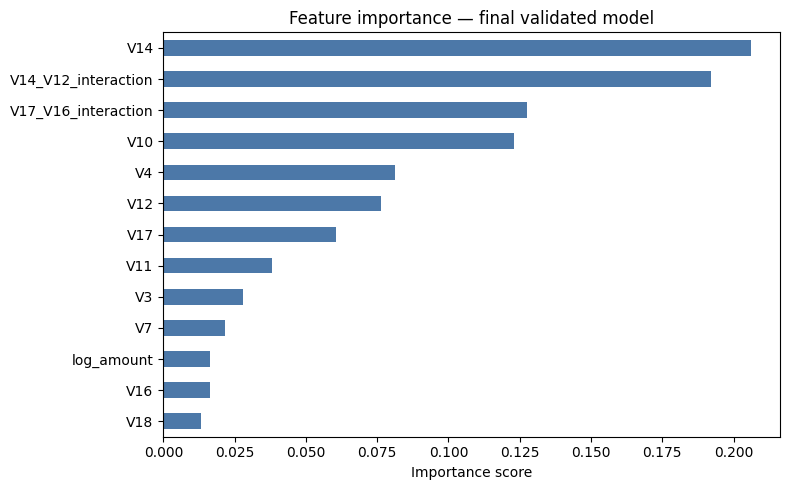

Saved feature importances to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/17_final_model_training/final_model_feature_importances.png


In [103]:
import matplotlib.pyplot as plt

feature_importances = pd.Series(
    final_model.feature_importances_,
    index=APPROVED_FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feature_importances.plot(kind="barh", ax=ax, color="#4C78A8")
ax.set_title("Feature importance — final validated model")
ax.set_xlabel("Importance score")
plt.tight_layout()
fi_path = FIGURES_DIR / "final_model_feature_importances.png"
plt.savefig(fi_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved feature importances to: {fi_path}")


### Generate Fraud Probabilities on Test Data

`predict_proba` returns two probabilities for each transaction: the probability of class `0` (normal transaction) and the probability of class `1` (fraud transaction). This project needs fraud risk, so it uses `[:, 1]`, which selects the probability of the fraud class.


In [104]:
y_test_proba = final_model.predict_proba(X_test)[:, 1]

print(f"Test probability shape: {y_test_proba.shape}")
print(f"Minimum fraud probability: {y_test_proba.min():.6f}")
print(f"Maximum fraud probability: {y_test_proba.max():.6f}")
print(f"Mean fraud probability: {y_test_proba.mean():.6f}")


Test probability shape: (56746,)
Minimum fraud probability: 0.000000
Maximum fraud probability: 1.000000
Mean fraud probability: 0.001451


### Probability Preview Table

This preview shows the first few hidden-test transactions with their actual labels and fraud probabilities. It is only a sanity check on the probability output, not a performance evaluation.


In [105]:
probability_preview = pd.DataFrame({
    "actual_class": y_test.iloc[:10].values,
    "fraud_probability": y_test_proba[:10],
})

probability_preview_path = TABLES_DIR / "final_model_probability_preview.csv"
probability_preview.to_csv(probability_preview_path, index=False)
display(probability_preview)
print(f"Saved probability preview to: {probability_preview_path}")


,actual_class,fraud_probability
0,0,0.000000
1,0,0.000000
2,0,0.000000
3,0,0.000000
4,0,0.000000
5,0,0.000000
6,0,0.000000
7,0,0.000000
8,0,0.000000
9,0,0.000000


Saved probability preview to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/final_model_probability_preview.csv


### Training Run Summary

This summary records the most important facts about the final training run up to probability generation. It provides a compact checkpoint before the notebook moves into final evaluation.


In [106]:
training_run_summary = pd.DataFrame(
    [
        {
            "model_name": FINAL_MODEL_NAME,
            "training_rows": X_train.shape[0],
            "test_rows": X_test.shape[0],
            "feature_count": X_train.shape[1],
            "target_column": TARGET_COL,
            "probability_output_created": True,
            "min_fraud_probability": float(y_test_proba.min()),
            "max_fraud_probability": float(y_test_proba.max()),
            "mean_fraud_probability": float(y_test_proba.mean()),
        }
    ]
)

training_run_summary_path = TABLES_DIR / "final_model_training_run_summary.csv"
training_run_summary.to_csv(training_run_summary_path, index=False)
display(training_run_summary)
print(f"Saved training run summary to: {training_run_summary_path}")


,model_name,training_rows,test_rows,feature_count,target_column,probability_output_created,min_fraud_probability,max_fraud_probability,mean_fraud_probability
0,Random Forest,226980,56746,13,Class,True,0.000000,1.000000,0.001451


Saved training run summary to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/final_model_training_run_summary.csv


### Probability Output Explanation

The model does not only produce a hard fraud/non-fraud label. It also produces a fraud probability between `0` and `1`. This probability is important because the decision policy uses it to decide whether a transaction should be `APPROVE`d, sent for `REVIEW`, or `BLOCK`ed.

For example, if `fraud_probability = 0.73`, the model estimates that the transaction has high fraud risk. The final business decision will depend on whether `0.73` is above the review or block threshold.


## Stop and Verify Before Final Evaluation

- Did model training complete successfully?
- Was the model trained only on `X_train` and `y_train`?
- Was `X_test` kept hidden during training?
- Can the model produce fraud probabilities?
- Do I understand why `predict_proba` is used?
- Do I understand why `[:, 1]` means fraud-class probability?
- Was `y_test_proba` created successfully?
- Was the training summary saved successfully?


## Final Model Holdout Evaluation

The final trained model is evaluated on the holdout test set. This test data was not used during training, so it gives a more honest estimate of how the model may perform on unseen transactions.

- The model was trained only on training data.
- The test set is used only for evaluation.
- Fraud detection should not be judged by accuracy alone.
- Precision, recall, F1-score, ROC-AUC, and PR-AUC are more useful for this project.


### Evaluation Safety Checks

Before calculating metrics, the notebook confirms that the trained model, hidden-test labels, and fraud probabilities are all available and structurally valid.


In [107]:
required_objects = ["final_model", "X_test", "y_test", "y_test_proba"]

for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(f"{obj_name} is required for final model evaluation but was not found.")

if len(y_test) != len(y_test_proba):
    raise ValueError("y_test and y_test_proba must have the same length.")

if not set(pd.Series(y_test).unique()).issubset({0, 1}):
    raise ValueError("y_test must contain only 0 and 1.")

if np.min(y_test_proba) < 0 or np.max(y_test_proba) > 1:
    raise ValueError("Predicted probabilities must be between 0 and 1.")

print("Final evaluation safety checks passed.")


Final evaluation safety checks passed.


### Standard Classification Threshold for Metrics

A threshold of `0.50` is used here only to calculate standard classification metrics and the confusion matrix. The final business decisions will later use the loaded review and block thresholds.


In [108]:
EVALUATION_THRESHOLD = 0.50
# 0.50 is used here as a neutral statistical baseline, not as the business decision threshold.
# Business decisions use review_threshold and block_threshold loaded from decision_policy.json.
# Reporting at 0.50 allows comparison with external benchmarks; the policy thresholds are applied separately.
y_test_pred = (y_test_proba >= EVALUATION_THRESHOLD).astype(int)


### Final Evaluation Metrics

These metrics summarise how well the final trained model separates fraud from normal transactions on unseen test data.


In [109]:
final_precision = precision_score(y_test, y_test_pred, zero_division=0)
final_recall = recall_score(y_test, y_test_pred, zero_division=0)
final_f1 = f1_score(y_test, y_test_pred, zero_division=0)
final_roc_auc = roc_auc_score(y_test, y_test_proba)
final_pr_auc = average_precision_score(y_test, y_test_proba)

final_metrics_df = pd.DataFrame(
    [
        {
            "metric": "Precision",
            "value": final_precision,
            "meaning": "Of the transactions predicted as fraud, how many were actually fraud.",
        },
        {
            "metric": "Recall",
            "value": final_recall,
            "meaning": "Of the actual fraud transactions, how many the model caught.",
        },
        {
            "metric": "F1-score",
            "value": final_f1,
            "meaning": "Balance between precision and recall.",
        },
        {
            "metric": "ROC-AUC",
            "value": final_roc_auc,
            "meaning": "General ability of the model to rank fraud higher than normal transactions.",
        },
        {
            "metric": "PR-AUC",
            "value": final_pr_auc,
            "meaning": "Precision-recall performance, especially useful for imbalanced fraud data.",
        },
    ]
)

display(final_metrics_df)


,metric,value,meaning
0,Precision,0.958904,"Of the transactions predicted as fraud, how ma..."
1,Recall,0.736842,"Of the actual fraud transactions, how many the..."
2,F1-score,0.833333,Balance between precision and recall.
3,ROC-AUC,0.928907,General ability of the model to rank fraud hig...
4,PR-AUC,0.814466,"Precision-recall performance, especially usefu..."


### Save Final Metrics Artifacts

The main evaluation metrics are saved both as a JSON artifact and as a reporting table so the final training notebook leaves behind reusable outputs for later inference and API integration work.


In [110]:
final_model_metrics = {
    "model_name": FINAL_MODEL_NAME,
    "evaluation_threshold": EVALUATION_THRESHOLD,
    "precision": final_precision,
    "recall": final_recall,
    "f1_score": final_f1,
    "roc_auc": final_roc_auc,
    "pr_auc": final_pr_auc,
    "test_rows": int(len(y_test)),
    "test_fraud_cases": int(pd.Series(y_test).sum()),
    "test_normal_cases": int(len(y_test) - pd.Series(y_test).sum()),
}

with open(FINAL_MODEL_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(final_model_metrics, f, indent=4)

final_model_metrics_table_path = TABLES_DIR / "final_model_evaluation_metrics.csv"
final_metrics_df.to_csv(final_model_metrics_table_path, index=False)

print(f"Saved final model metrics JSON to: {FINAL_MODEL_METRICS_PATH}")
print(f"Saved final evaluation metrics table to: {final_model_metrics_table_path}")


Saved final model metrics JSON to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/final_model_metrics.json
Saved final evaluation metrics table to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/final_model_evaluation_metrics.csv


### Classification Report

The classification report gives class-level precision, recall, and F1-score for both normal and fraud transactions at the standard `0.50` threshold.


In [111]:
classification_report_dict = classification_report(
    y_test,
    y_test_pred,
    target_names=["Normal Transaction", "Fraud Transaction"],
    output_dict=True,
    zero_division=0,
)

classification_report_df = pd.DataFrame(classification_report_dict).transpose()
classification_report_path = TABLES_DIR / "final_classification_report.csv"
classification_report_df.to_csv(classification_report_path)
display(classification_report_df)
print(f"Saved classification report to: {classification_report_path}")


,precision,recall,f1-score,support
Normal Transaction,0.999559,0.999947,0.999753,56651.000000
Fraud Transaction,0.958904,0.736842,0.833333,95.000000
accuracy,0.999507,0.999507,0.999507,0.999507
macro avg,0.979231,0.868395,0.916543,56746.000000
weighted avg,0.999491,0.999507,0.999474,56746.000000


Saved classification report to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/final_classification_report.csv


### Confusion Matrix

The confusion matrix shows how many normal and fraud transactions were classified correctly or incorrectly at the standard `0.50` threshold.


In [112]:
cm = confusion_matrix(y_test, y_test_pred)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=["Actual Normal", "Actual Fraud"],
    columns=["Predicted Normal", "Predicted Fraud"],
)

confusion_matrix_path = TABLES_DIR / "final_confusion_matrix.csv"
confusion_matrix_df.to_csv(confusion_matrix_path)
display(confusion_matrix_df)
print(f"Saved confusion matrix to: {confusion_matrix_path}")


,Predicted Normal,Predicted Fraud
Actual Normal,56648,3
Actual Fraud,25,70


Saved confusion matrix to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/final_confusion_matrix.csv


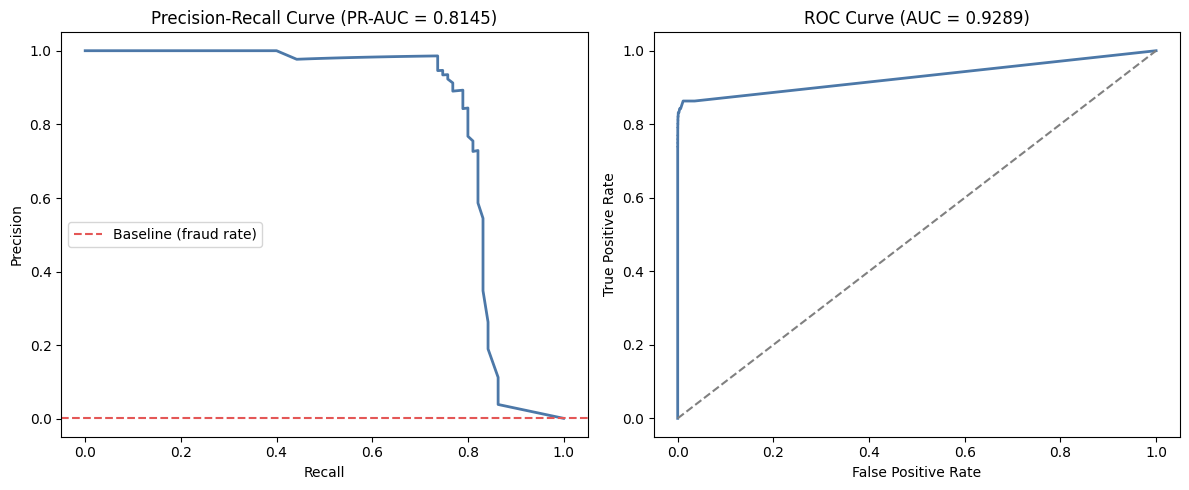

Saved PR and ROC curves to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/17_final_model_training/final_model_pr_roc_curves.png


In [113]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_proba)
axes[0].plot(recall_vals, precision_vals, color="#4C78A8", lw=2)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"Precision-Recall Curve (PR-AUC = {final_pr_auc:.4f})")
axes[0].axhline(y=y_test.mean(), color="#E45756", linestyle="--", label="Baseline (fraud rate)")
axes[0].legend()

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[1].plot(fpr, tpr, color="#4C78A8", lw=2)
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title(f"ROC Curve (AUC = {final_roc_auc:.4f})")

plt.tight_layout()
pr_roc_curve_path = FIGURES_DIR / "final_model_pr_roc_curves.png"
plt.savefig(pr_roc_curve_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved PR and ROC curves to: {pr_roc_curve_path}")


### Confusion Matrix Interpretation

- True Negative: normal transaction correctly predicted as normal.
- False Positive: normal transaction incorrectly predicted as fraud.
- False Negative: fraud transaction incorrectly predicted as normal.
- True Positive: fraud transaction correctly predicted as fraud.

For fraud detection, false negatives are very important because they represent fraud cases that were missed.


## Final Evaluation Metric Interpretation

**Precision:** High precision means fewer normal transactions are wrongly flagged as fraud.

**Recall:** High recall means the model catches more fraud cases.

**F1-score:** Useful when we need balance between catching fraud and avoiding too many false alarms.

**ROC-AUC:** Measures ranking ability across thresholds.

**PR-AUC:** Very important in fraud detection because fraud cases are rare and the dataset is imbalanced.

> Accuracy is not the main metric for this project because the dataset is highly imbalanced. A model can get high accuracy by predicting almost everything as normal, but that would fail to catch fraud.


### Evaluation Readiness Summary

This summary confirms that the final model has been evaluated, the key outputs were saved, and the notebook is ready to move into business decision logic using the previously approved thresholds.


In [114]:
evaluation_readiness_summary = pd.DataFrame(
    [
        {"check": "final_model_trained", "value": True},
        {"check": "y_test_proba_available", "value": True},
        {"check": "evaluation_threshold", "value": EVALUATION_THRESHOLD},
        {"check": "metrics_calculated", "value": True},
        {"check": "classification_report_saved", "value": True},
        {"check": "confusion_matrix_saved", "value": True},
        {"check": "metrics_json_saved", "value": True},
        {"check": "ready_for_decision_logic", "value": True},
    ]
)

display(evaluation_readiness_summary)


,check,value
0,final_model_trained,True
1,y_test_proba_available,True
2,evaluation_threshold,0.500000
3,metrics_calculated,True
4,classification_report_saved,True
5,confusion_matrix_saved,True
6,metrics_json_saved,True
7,ready_for_decision_logic,True


## Stop and Verify Before Decision Logic Application

- Did final model evaluation complete successfully?
- Is recall acceptable for fraud detection?
- Is precision acceptable?
- Is F1-score reported?
- Is ROC-AUC reported?
- Is PR-AUC reported?
- Do I understand why PR-AUC is important for imbalanced fraud data?
- Do I understand the confusion matrix?
- Were `final_model_metrics.json`, `final_classification_report.csv`, and `final_confusion_matrix.csv` saved successfully?


## Final Business Decision Logic Application

The trained model produces a fraud probability between `0` and `1`. However, a business system needs an action. This section converts each fraud probability into one of three decisions: `APPROVE`, `REVIEW`, or `BLOCK`.

- Probability alone is not the final output.
- Thresholds convert probability into a decision.
- The thresholds are reused from the saved decision policy.
- This notebook does not invent or tune new thresholds.


### Decision Logic Safety Checks

Before applying the business rules, the notebook confirms that test probabilities and approved thresholds are available and valid.


In [115]:
required_decision_objects = ["y_test", "y_test_proba", "review_threshold", "block_threshold"]

for obj_name in required_decision_objects:
    if obj_name not in globals():
        raise NameError(f"{obj_name} is required before applying decision logic but was not found.")

if "assign_decision" not in globals():
    def assign_decision(probability, review_threshold, block_threshold):
        if probability < 0 or probability > 1:
            raise ValueError("Probability must be between 0 and 1.")
        if probability >= block_threshold:
            return "BLOCK"
        elif probability >= review_threshold:
            return "REVIEW"
        return "APPROVE"

if len(y_test) != len(y_test_proba):
    raise ValueError("y_test and y_test_proba must have the same length.")

if np.min(y_test_proba) < 0 or np.max(y_test_proba) > 1:
    raise ValueError("y_test_proba values must be between 0 and 1.")

if not 0 <= review_threshold <= 1:
    raise ValueError("review_threshold must be between 0 and 1.")

if not 0 <= block_threshold <= 1:
    raise ValueError("block_threshold must be between 0 and 1.")

if review_threshold >= block_threshold:
    raise ValueError("review_threshold must be less than block_threshold.")

print("Decision logic safety checks passed.")


Decision logic safety checks passed.


### Decision Function

This function applies the same business decision rule to every predicted fraud probability.


### Apply Decision Logic to Test Predictions

The table below combines the actual class, predicted fraud probability, and final business decision for each holdout test transaction.


In [116]:
final_decision_results = pd.DataFrame({
    "actual_class": y_test.values if hasattr(y_test, "values") else y_test,
    "fraud_probability": y_test_proba,
})

final_decision_results["final_decision"] = final_decision_results["fraud_probability"].apply(
    lambda probability: assign_decision(
        probability=probability,
        review_threshold=review_threshold,
        block_threshold=block_threshold,
    )
)

final_decision_results["actual_class_label"] = final_decision_results["actual_class"].map({
    0: "Normal Transaction",
    1: "Fraud Transaction",
})

display(final_decision_results.head(10))


,actual_class,fraud_probability,final_decision,actual_class_label
0,0,0.000000,APPROVE,Normal Transaction
1,0,0.000000,APPROVE,Normal Transaction
2,0,0.000000,APPROVE,Normal Transaction
3,0,0.000000,APPROVE,Normal Transaction
4,0,0.000000,APPROVE,Normal Transaction
5,0,0.000000,APPROVE,Normal Transaction
6,0,0.000000,APPROVE,Normal Transaction
7,0,0.000000,APPROVE,Normal Transaction
8,0,0.000000,APPROVE,Normal Transaction
9,0,0.000000,APPROVE,Normal Transaction


### Decision Summary Table

This summary shows the size and fraud composition of each business decision group, along with the probability range inside each group.


In [117]:
total_fraud_cases = int(final_decision_results["actual_class"].sum())

decision_summary = final_decision_results.groupby("final_decision").agg(
    total_transactions=("actual_class", "count"),
    normal_transactions=("actual_class", lambda x: (x == 0).sum()),
    fraud_transactions=("actual_class", lambda x: (x == 1).sum()),
    average_fraud_probability=("fraud_probability", "mean"),
    minimum_fraud_probability=("fraud_probability", "min"),
    maximum_fraud_probability=("fraud_probability", "max"),
).reset_index()

decision_summary["fraud_capture_percentage"] = (
    decision_summary["fraud_transactions"] / total_fraud_cases * 100
) if total_fraud_cases else 0.0

decision_order = {"APPROVE": 0, "REVIEW": 1, "BLOCK": 2}
decision_summary["decision_order"] = decision_summary["final_decision"].map(decision_order)
decision_summary = decision_summary.sort_values("decision_order").drop(columns=["decision_order"]).reset_index(drop=True)

display(decision_summary)


,final_decision,total_transactions,normal_transactions,fraud_transactions,average_fraud_probability,minimum_fraud_probability,maximum_fraud_probability,fraud_capture_percentage
0,APPROVE,56672,56647,25,0.000271,0.000000,0.296667,26.315789
1,REVIEW,1,1,0,0.390000,0.390000,0.390000,0.000000
2,BLOCK,73,3,70,0.912648,0.566667,1.000000,73.684211


### Decision Volume Summary

These totals translate the model output into business workflow volume: how many transactions are approved automatically, how many need review, and how many are blocked.


In [118]:
approved_count = int((final_decision_results["final_decision"] == "APPROVE").sum())
review_count = int((final_decision_results["final_decision"] == "REVIEW").sum())
blocked_count = int((final_decision_results["final_decision"] == "BLOCK").sum())

fraud_approved = int(((final_decision_results["actual_class"] == 1) & (final_decision_results["final_decision"] == "APPROVE")).sum())
fraud_review = int(((final_decision_results["actual_class"] == 1) & (final_decision_results["final_decision"] == "REVIEW")).sum())
fraud_blocked = int(((final_decision_results["actual_class"] == 1) & (final_decision_results["final_decision"] == "BLOCK")).sum())

fraud_caught_review_or_block = final_decision_results[(final_decision_results["actual_class"] == 1) & (final_decision_results["final_decision"].isin(["REVIEW", "BLOCK"]))].shape[0]
fraud_caught_percentage = (fraud_caught_review_or_block / total_fraud_cases * 100) if total_fraud_cases else 0.0

print(f"Total approved transactions: {approved_count}")
print(f"Total review transactions: {review_count}")
print(f"Total blocked transactions: {blocked_count}")
print(f"Fraud cases approved: {fraud_approved}")
print(f"Fraud cases sent to review: {fraud_review}")
print(f"Fraud cases blocked: {fraud_blocked}")
print(f"Fraud cases caught in REVIEW or BLOCK: {fraud_caught_review_or_block} out of {total_fraud_cases}")
print(f"Fraud capture rate by business policy: {fraud_caught_percentage:.2f}%")
fraud_approved_rate = (fraud_approved / total_fraud_cases * 100) if total_fraud_cases else 0.0
print(f"\n[RISK CHECK] Fraud cases slipping through as APPROVED: {fraud_approved} ({fraud_approved_rate:.1f}% of all fraud)")
if fraud_approved_rate > 5.0:
    print("  WARNING: More than 5% of fraud cases are being approved. Review decision thresholds.")
else:
    print("  OK: Fraud-approved rate is within acceptable range.")


Total approved transactions: 56672
Total review transactions: 1
Total blocked transactions: 73
Fraud cases approved: 25
Fraud cases sent to review: 0
Fraud cases blocked: 70
Fraud cases caught in REVIEW or BLOCK: 70 out of 95
Fraud capture rate by business policy: 73.68%

[RISK CHECK] Fraud cases slipping through as APPROVED: 25 (26.3% of all fraud)


### Save Decision Results and Summary

The full transaction-level decision output and the grouped decision summary are both saved for reporting and later artifact packaging.


In [119]:
final_decision_results_path = TABLES_DIR / "final_decision_results.csv"
final_decision_summary_path = TABLES_DIR / "final_decision_summary.csv"

final_decision_results.to_csv(final_decision_results_path, index=False)
decision_summary.to_csv(final_decision_summary_path, index=False)

print(f"Saved decision results to: {final_decision_results_path}")
print(f"Saved decision summary to: {final_decision_summary_path}")


Saved decision results to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/final_decision_results.csv
Saved decision summary to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/final_decision_summary.csv


## Business Decision Interpretation

**APPROVE:** Transactions below the review threshold are considered low risk.

**REVIEW:** Transactions between the review threshold and block threshold require manual or secondary review.

**BLOCK:** Transactions above the block threshold are considered high risk and should be blocked.

For fraud detection, the most important question is not only how many transactions were blocked. We also need to check how many actual fraud cases were captured in `REVIEW` or `BLOCK`.


### Decision Logic Examples

These sample probabilities show how the same thresholds produce different business actions.


In [120]:
example_probabilities = [
    max(0.0, review_threshold / 2),
    (review_threshold + block_threshold) / 2,
    min(1.0, block_threshold + 0.10),
]

example_decision_logic = pd.DataFrame({
    "example_fraud_probability": example_probabilities,
    "applied_rule": [
        f"probability < {review_threshold:.3f}",
        f"{review_threshold:.3f} <= probability < {block_threshold:.3f}",
        f"probability >= {block_threshold:.3f}",
    ],
    "final_decision": [
        assign_decision(prob, review_threshold, block_threshold)
        for prob in example_probabilities
    ],
})

display(example_decision_logic)


,example_fraud_probability,applied_rule,final_decision
0,0.175000,probability < 0.350,APPROVE
1,0.425000,0.350 <= probability < 0.500,REVIEW
2,0.600000,probability >= 0.500,BLOCK


### Decision Logic Readiness Summary

This summary confirms that the saved decision policy was reused correctly and that business decisions are now available for the holdout test predictions.


In [121]:
decision_logic_readiness_summary = pd.DataFrame(
    [
        {"check": "decision_policy_loaded", "value": True},
        {"check": "review_threshold", "value": review_threshold},
        {"check": "block_threshold", "value": block_threshold},
        {"check": "test_probabilities_available", "value": True},
        {"check": "decisions_created", "value": True},
        {"check": "decision_results_saved", "value": True},
        {"check": "decision_summary_saved", "value": True},
        {"check": "ready_for_artifact_saving", "value": True},
    ]
)

display(decision_logic_readiness_summary)


,check,value
0,decision_policy_loaded,True
1,review_threshold,0.350000
2,block_threshold,0.500000
3,test_probabilities_available,True
4,decisions_created,True
5,decision_results_saved,True
6,decision_summary_saved,True
7,ready_for_artifact_saving,True


## Stop and Verify Before Artifact Saving

- How many transactions were approved?
- How many transactions were sent to review?
- How many transactions were blocked?
- How many actual fraud cases were approved?
- How many actual fraud cases were caught in `REVIEW` or `BLOCK`?
- Do I understand how probability becomes a business decision?
- Were decision results and summary tables saved successfully?
- Am I reusing thresholds instead of creating new ones?


## Final Artifact Saving for Inference

The notebook has trained and evaluated the final fraud detection model. Now the trained model and supporting files must be saved to disk so that the inference pipeline and FastAPI application can load them later.

- Notebook variables disappear when the notebook is closed.
- FastAPI cannot directly access notebook memory.
- Saved artifacts allow the model to be reused outside the notebook.
- Feature columns are saved to keep prediction input order consistent.
- Decision policy is saved so API predictions use the same `APPROVE` / `REVIEW` / `BLOCK` rules.


### Artifact Saving Safety Checks

Before writing files to disk, the notebook confirms that the trained model, metrics, thresholds, and decision outputs already exist and are valid for inference packaging.


In [122]:
from sklearn.utils.validation import check_is_fitted

required_artifact_objects = [
    "final_model",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "decision_policy",
    "review_threshold",
    "block_threshold",
    "final_decision_results",
]

for obj_name in required_artifact_objects:
    if obj_name not in globals():
        raise NameError(f"{obj_name} is required before saving artifacts but was not found.")

if "final_model_metrics" not in globals():
    final_model_metrics = {
        "model_name": FINAL_MODEL_NAME,
        "evaluation_threshold": EVALUATION_THRESHOLD if "EVALUATION_THRESHOLD" in globals() else 0.50,
        "precision": float(final_precision),
        "recall": float(final_recall),
        "f1_score": float(final_f1),
        "roc_auc": float(final_roc_auc),
        "pr_auc": float(final_pr_auc),
        "test_rows": int(len(y_test)),
        "test_fraud_cases": int(pd.Series(y_test).sum()),
        "test_normal_cases": int(len(y_test) - pd.Series(y_test).sum()),
    }

try:
    check_is_fitted(final_model)
    print("Final model is fitted and ready to save.")
except Exception as e:
    raise RuntimeError("Final model must be trained before saving artifacts.") from e

if not hasattr(X_train, "columns") or len(X_train.columns) == 0:
    raise ValueError("X_train must contain feature columns before saving artifacts.")

if not 0 <= review_threshold <= 1 or not 0 <= block_threshold <= 1:
    raise ValueError("review_threshold and block_threshold must both be between 0 and 1.")

if review_threshold >= block_threshold:
    raise ValueError("review_threshold must be less than block_threshold.")

print("Artifact saving safety checks passed.")


Final model is fitted and ready to save.
Artifact saving safety checks passed.


### Save Final Trained Model

The trained model object is saved with `joblib` so the inference pipeline can load it later without retraining.


In [123]:
joblib.dump(final_model, FINAL_MODEL_PATH)
print(f"Final model saved successfully: {FINAL_MODEL_PATH}")


Final model saved successfully: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/final_validated_fraud_model.joblib


### Save Final Feature Columns

Feature column order is critical for inference. The API must send input features in the same order used during model training.


In [124]:
final_feature_columns = list(X_train.columns)

with open(FINAL_FEATURE_COLUMNS_PATH, "w", encoding="utf-8") as f:
    json.dump(final_feature_columns, f, indent=4)

print(f"Feature columns saved successfully: {FINAL_FEATURE_COLUMNS_PATH}")
print(f"Number of feature columns saved: {len(final_feature_columns)}")


Feature columns saved successfully: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/final_feature_columns.json
Number of feature columns saved: 13


### Save Final Model Metadata

Metadata records how the final model was trained, which thresholds it uses, and where the related artifact files are stored.


In [125]:
final_model_metadata = {
    "model_name": FINAL_MODEL_NAME,
    "model_type": type(final_model).__name__,
    "training_timestamp": datetime.now().isoformat(),
    "target_column": TARGET_COL,
    "feature_count": len(final_feature_columns),
    "training_rows": int(X_train.shape[0]),
    "test_rows": int(X_test.shape[0]),
    "source_dataset_rows_after_duplicate_removal": int(df_model.shape[0]) if "df_model" in globals() else None,
    "duplicates_removed": int(df.shape[0] - df_model.shape[0]) if "df" in globals() and "df_model" in globals() else None,
    "evaluation_threshold": EVALUATION_THRESHOLD if "EVALUATION_THRESHOLD" in globals() else 0.50,
    "review_threshold": review_threshold,
    "block_threshold": block_threshold,
    "decision_labels": {
        "approve": "APPROVE",
        "review": "REVIEW",
        "block": "BLOCK",
    },
    "artifact_files": {
        "model": str(FINAL_MODEL_PATH),
        "feature_columns": str(FINAL_FEATURE_COLUMNS_PATH),
        "metrics": str(FINAL_MODEL_METRICS_PATH),
        "decision_policy": str(FINAL_DECISION_POLICY_PATH),
    },
    "intended_usage": "Final validated fraud detection model for inference pipeline and FastAPI prediction endpoint",
}

with open(FINAL_MODEL_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(final_model_metadata, f, indent=4)

print(f"Model metadata saved successfully: {FINAL_MODEL_METADATA_PATH}")


Model metadata saved successfully: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/final_model_metadata.json


### Save Final Model Metrics

The final holdout metrics are saved again here to make sure the inference artifact bundle contains a clean evaluation record.


In [126]:
def convert_numpy_types(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

with open(FINAL_MODEL_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(final_model_metrics, f, indent=4, default=convert_numpy_types)

print(f"Final model metrics saved successfully: {FINAL_MODEL_METRICS_PATH}")


Final model metrics saved successfully: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/final_model_metrics.json


### Save Final Decision Policy Copy

The final decision policy artifact keeps the validated thresholds and decision rules alongside the trained model artifacts so the API can apply the same business logic later.


In [127]:
final_decision_policy = {
    "review_threshold": review_threshold,
    "block_threshold": block_threshold,
    "decision_labels": {
        "approve": "APPROVE",
        "review": "REVIEW",
        "block": "BLOCK",
    },
    "decision_rules": {
        "APPROVE": f"probability < {review_threshold}",
        "REVIEW": f"{review_threshold} <= probability < {block_threshold}",
        "BLOCK": f"probability >= {block_threshold}",
    },
    "source_policy_file": str(DECISION_POLICY_PATH),
    "note": "Decision policy reused from threshold tuning and decision logic notebooks. No new thresholds were created in final model training.",
}

with open(FINAL_DECISION_POLICY_PATH, "w", encoding="utf-8") as f:
    json.dump(final_decision_policy, f, indent=4)

print(f"Final decision policy saved successfully: {FINAL_DECISION_POLICY_PATH}")


Final decision policy saved successfully: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/final_decision_policy.json


### Verify Saved Artifacts

After saving, the notebook checks that every required artifact exists on disk and records its file size and purpose.


In [128]:
artifact_verification_rows = [
    {
        "artifact_name": "final_validated_fraud_model.joblib",
        "file_path": str(FINAL_MODEL_PATH),
        "exists": FINAL_MODEL_PATH.exists(),
        "file_size_kb": round(FINAL_MODEL_PATH.stat().st_size / 1024, 2) if FINAL_MODEL_PATH.exists() else 0.0,
        "purpose": "Trained model used for prediction",
    },
    {
        "artifact_name": "final_feature_columns.json",
        "file_path": str(FINAL_FEATURE_COLUMNS_PATH),
        "exists": FINAL_FEATURE_COLUMNS_PATH.exists(),
        "file_size_kb": round(FINAL_FEATURE_COLUMNS_PATH.stat().st_size / 1024, 2) if FINAL_FEATURE_COLUMNS_PATH.exists() else 0.0,
        "purpose": "Correct feature order for inference/API input",
    },
    {
        "artifact_name": "final_model_metadata.json",
        "file_path": str(FINAL_MODEL_METADATA_PATH),
        "exists": FINAL_MODEL_METADATA_PATH.exists(),
        "file_size_kb": round(FINAL_MODEL_METADATA_PATH.stat().st_size / 1024, 2) if FINAL_MODEL_METADATA_PATH.exists() else 0.0,
        "purpose": "Model training and artifact information",
    },
    {
        "artifact_name": "final_model_metrics.json",
        "file_path": str(FINAL_MODEL_METRICS_PATH),
        "exists": FINAL_MODEL_METRICS_PATH.exists(),
        "file_size_kb": round(FINAL_MODEL_METRICS_PATH.stat().st_size / 1024, 2) if FINAL_MODEL_METRICS_PATH.exists() else 0.0,
        "purpose": "Final holdout evaluation metrics",
    },
    {
        "artifact_name": "final_decision_policy.json",
        "file_path": str(FINAL_DECISION_POLICY_PATH),
        "exists": FINAL_DECISION_POLICY_PATH.exists(),
        "file_size_kb": round(FINAL_DECISION_POLICY_PATH.stat().st_size / 1024, 2) if FINAL_DECISION_POLICY_PATH.exists() else 0.0,
        "purpose": "Thresholds and APPROVE / REVIEW / BLOCK rules",
    },
]

artifact_verification_summary = pd.DataFrame(artifact_verification_rows)
artifact_verification_summary_path = TABLES_DIR / "final_artifact_verification_summary.csv"
artifact_verification_summary.to_csv(artifact_verification_summary_path, index=False)
display(artifact_verification_summary)
print(f"Saved artifact verification summary to: {artifact_verification_summary_path}")


,artifact_name,file_path,exists,file_size_kb,purpose
0,final_validated_fraud_model.joblib,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...,True,8786.740000,Trained model used for prediction
1,final_feature_columns.json,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...,True,0.180000,Correct feature order for inference/API input
2,final_model_metadata.json,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...,True,1.120000,Model training and artifact information
3,final_model_metrics.json,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...,True,0.320000,Final holdout evaluation metrics
4,final_decision_policy.json,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...,True,0.580000,Thresholds and APPROVE / REVIEW / BLOCK rules


Saved artifact verification summary to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/final_artifact_verification_summary.csv


## Saved Artifact Usage

- `final_validated_fraud_model.joblib` -> trained model used to generate fraud probabilities
- `final_feature_columns.json` -> correct input column order for inference
- `final_model_metadata.json` -> model details, training information, and artifact references
- `final_model_metrics.json` -> final model performance results
- `final_decision_policy.json` -> thresholds and decision rules for `APPROVE` / `REVIEW` / `BLOCK`

These files will be used in the next inference pipeline notebook and later by the FastAPI `/predict` endpoint.


### Artifact Readiness Summary

This summary confirms that all required inference files have been saved and verified on disk.


In [129]:
all_required_artifacts_exist = bool(artifact_verification_summary["exists"].all())

artifact_readiness_summary = pd.DataFrame(
    [
        {"check": "model_saved", "value": FINAL_MODEL_PATH.exists()},
        {"check": "feature_columns_saved", "value": FINAL_FEATURE_COLUMNS_PATH.exists()},
        {"check": "metadata_saved", "value": FINAL_MODEL_METADATA_PATH.exists()},
        {"check": "metrics_saved", "value": FINAL_MODEL_METRICS_PATH.exists()},
        {"check": "decision_policy_saved", "value": FINAL_DECISION_POLICY_PATH.exists()},
        {"check": "all_required_artifacts_exist", "value": all_required_artifacts_exist},
        {"check": "ready_for_saved_artifact_test", "value": all_required_artifacts_exist},
        {"check": "ready_for_inference_pipeline", "value": all_required_artifacts_exist},
    ]
)

display(artifact_readiness_summary)


,check,value
0,model_saved,True
1,feature_columns_saved,True
2,metadata_saved,True
3,metrics_saved,True
4,decision_policy_saved,True
5,all_required_artifacts_exist,True
6,ready_for_saved_artifact_test,True
7,ready_for_inference_pipeline,True


## Stop and Verify Before Saved Artifact Testing

- Does `final_validated_fraud_model.joblib` exist?
- Does `final_feature_columns.json` exist?
- Does `final_model_metadata.json` exist?
- Does `final_model_metrics.json` exist?
- Does `final_decision_policy.json` exist?
- Can I explain why FastAPI needs saved files instead of notebook variables?
- Can I explain what each artifact is used for?
- Is the project ready to test reloading the saved artifacts?


## Saved Artifact Reload and Prediction Test

The final model was already trained and saved. This section reloads the saved files from disk and tests whether they can produce a complete prediction response. This is important because FastAPI will not use notebook variables directly. It will load saved artifacts from files.

- This test proves the model artifact can be loaded.
- This test proves feature columns can be reused in the correct order.
- This test proves the decision policy can convert probability into `APPROVE`, `REVIEW`, or `BLOCK`.
- This output is similar to what the future API response will return.


### Artifact Reload Safety Checks

Before reloading anything, the notebook verifies that the required saved artifacts are present on disk.


In [130]:
required_artifact_paths = {
    "model": FINAL_MODEL_PATH,
    "feature_columns": FINAL_FEATURE_COLUMNS_PATH,
    "decision_policy": FINAL_DECISION_POLICY_PATH,
}

for artifact_name, artifact_path in required_artifact_paths.items():
    if not artifact_path.exists():
        raise FileNotFoundError(f"{artifact_name} artifact not found: {artifact_path}")
    print(f"{artifact_name} artifact found: {artifact_path}")


model artifact found: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/final_validated_fraud_model.joblib
feature_columns artifact found: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/final_feature_columns.json
decision_policy artifact found: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/final_decision_policy.json


### Reload Saved Artifacts

This step reloads the trained model, saved feature order, and saved decision policy exactly as a future inference service would do.


In [131]:
loaded_model = joblib.load(FINAL_MODEL_PATH)

with open(FINAL_FEATURE_COLUMNS_PATH, "r", encoding="utf-8") as f:
    loaded_feature_columns = json.load(f)

with open(FINAL_DECISION_POLICY_PATH, "r", encoding="utf-8") as f:
    loaded_decision_policy = json.load(f)

print("Saved model reloaded successfully.")
print("Feature columns reloaded successfully.")
print("Decision policy reloaded successfully.")


Saved model reloaded successfully.
Feature columns reloaded successfully.
Decision policy reloaded successfully.


### Validate Reloaded Artifacts

After loading, the notebook checks that the artifacts have the right structure and contain the thresholds needed for business decision logic.


In [132]:
if not hasattr(loaded_model, "predict_proba"):
    raise TypeError("Reloaded model does not support predict_proba.")

if not isinstance(loaded_feature_columns, list) or not loaded_feature_columns:
    raise ValueError("Reloaded feature columns must be a non-empty list.")

if "review_threshold" not in loaded_decision_policy or "block_threshold" not in loaded_decision_policy:
    raise KeyError("Reloaded decision policy must contain review_threshold and block_threshold.")

loaded_review_threshold = loaded_decision_policy["review_threshold"]
loaded_block_threshold = loaded_decision_policy["block_threshold"]

if not isinstance(loaded_review_threshold, (int, float)) or not isinstance(loaded_block_threshold, (int, float)):
    raise TypeError("Reloaded thresholds must be numeric.")

if loaded_review_threshold >= loaded_block_threshold:
    raise ValueError("Reloaded review_threshold must be less than reloaded block_threshold.")

print("Reloaded artifact validation passed.")


Reloaded artifact validation passed.


### Select and Align One Sample Transaction

A single holdout test transaction is used here to simulate one future API request. The sample is then aligned to the saved feature-column order before prediction.


In [133]:
sample_transaction = X_test.iloc[[0]].copy()
sample_actual_class = int(y_test.iloc[0]) if hasattr(y_test, "iloc") else int(y_test[0])

print("Sample transaction selected successfully.")
print(f"Actual class: {sample_actual_class}")

missing_columns = [col for col in loaded_feature_columns if col not in sample_transaction.columns]
extra_columns = [col for col in sample_transaction.columns if col not in loaded_feature_columns]

if missing_columns:
    raise ValueError(f"Sample transaction is missing required feature columns: {missing_columns}")

sample_transaction_aligned = sample_transaction[loaded_feature_columns].copy()

if list(sample_transaction_aligned.columns) != loaded_feature_columns:
    raise ValueError("Sample transaction columns are not aligned with saved feature columns.")

print("Sample transaction columns aligned successfully.")
print(f"Aligned sample shape: {sample_transaction_aligned.shape}")


Sample transaction selected successfully.
Actual class: 0
Sample transaction columns aligned successfully.
Aligned sample shape: (1, 13)


Feature alignment is very important because the model expects the same feature names and order used during training. This is why `final_feature_columns.json` is required for inference.


### Generate Probability and Apply Decision Policy

The reloaded model now produces a fraud probability, and the reloaded thresholds convert that probability into the final business decision.


In [134]:
sample_fraud_probability = loaded_model.predict_proba(sample_transaction_aligned)[:, 1][0]
sample_fraud_probability = float(sample_fraud_probability)
print(f"Fraud probability: {sample_fraud_probability:.6f}")

sample_decision = assign_decision(
    probability=sample_fraud_probability,
    review_threshold=loaded_review_threshold,
    block_threshold=loaded_block_threshold,
)

def generate_decision_reason(probability, decision, review_threshold, block_threshold):
    if decision == "BLOCK":
        return "Fraud probability is above the block threshold."
    elif decision == "REVIEW":
        return "Fraud probability is above the review threshold but below the block threshold."
    return "Fraud probability is below the review threshold."

sample_reason = generate_decision_reason(
    probability=sample_fraud_probability,
    decision=sample_decision,
    review_threshold=loaded_review_threshold,
    block_threshold=loaded_block_threshold,
)


Fraud probability: 0.000000


### API-Style Prediction Response

This response structure mirrors what a future FastAPI endpoint would return after loading the saved artifacts and scoring one incoming transaction.


In [135]:
sample_prediction_response = {
    "fraud_probability": round(sample_fraud_probability, 6),
    "decision": sample_decision,
    "reason": sample_reason,
    "model_name": FINAL_MODEL_NAME if "FINAL_MODEL_NAME" in globals() else type(loaded_model).__name__,
    "actual_class": sample_actual_class,
    "actual_class_label": "Fraud Transaction" if sample_actual_class == 1 else "Normal Transaction",
    "review_threshold": loaded_review_threshold,
    "block_threshold": loaded_block_threshold,
}

print(json.dumps(sample_prediction_response, indent=4))

SAMPLE_PREDICTION_RESPONSE_PATH = TABLES_DIR / "sample_saved_artifact_prediction_response.json"
with open(SAMPLE_PREDICTION_RESPONSE_PATH, "w", encoding="utf-8") as f:
    json.dump(sample_prediction_response, f, indent=4)

print(f"Saved sample prediction response to: {SAMPLE_PREDICTION_RESPONSE_PATH}")


{
    "fraud_probability": 0.0,
    "decision": "APPROVE",
    "reason": "Fraud probability is below the review threshold.",
    "model_name": "Random Forest",
    "actual_class": 0,
    "actual_class_label": "Normal Transaction",
    "review_threshold": 0.35,
    "block_threshold": 0.5
}
Saved sample prediction response to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/sample_saved_artifact_prediction_response.json


### Saved Artifact Test Summary

This summary records each step of the saved-artifact reload test so the notebook leaves a clear verification trail for the future inference pipeline.


In [136]:
artifact_test_results = {}

try:
    assert FINAL_MODEL_PATH.exists()
    artifact_test_results["Model artifact loaded"] = ("PASS", str(FINAL_MODEL_PATH))
except Exception as e:
    artifact_test_results["Model artifact loaded"] = ("FAIL", str(e))

try:
    assert isinstance(loaded_feature_columns, list) and len(loaded_feature_columns) > 0
    artifact_test_results["Feature columns loaded"] = ("PASS", f"{len(loaded_feature_columns)} columns loaded")
except Exception as e:
    artifact_test_results["Feature columns loaded"] = ("FAIL", str(e))

try:
    assert FINAL_DECISION_POLICY_PATH.exists()
    artifact_test_results["Decision policy loaded"] = ("PASS", str(FINAL_DECISION_POLICY_PATH))
except Exception as e:
    artifact_test_results["Decision policy loaded"] = ("FAIL", str(e))

try:
    assert sample_actual_class in {0, 1}
    artifact_test_results["Sample transaction selected"] = ("PASS", f"Actual class = {sample_actual_class}")
except Exception as e:
    artifact_test_results["Sample transaction selected"] = ("FAIL", str(e))

try:
    assert list(sample_transaction_aligned.columns) == loaded_feature_columns
    artifact_test_results["Feature columns aligned"] = ("PASS", f"Aligned shape = {sample_transaction_aligned.shape}")
except Exception as e:
    artifact_test_results["Feature columns aligned"] = ("FAIL", str(e))

try:
    assert 0.0 <= sample_fraud_probability <= 1.0
    artifact_test_results["Fraud probability generated"] = ("PASS", f"Probability = {sample_fraud_probability:.6f}")
except Exception as e:
    artifact_test_results["Fraud probability generated"] = ("FAIL", str(e))

try:
    assert sample_decision in {"APPROVE", "REVIEW", "BLOCK"}
    artifact_test_results["Business decision generated"] = ("PASS", sample_decision)
except Exception as e:
    artifact_test_results["Business decision generated"] = ("FAIL", str(e))

try:
    assert isinstance(sample_prediction_response, dict) and "fraud_probability" in sample_prediction_response
    artifact_test_results["API-style response created"] = ("PASS", sample_reason)
except Exception as e:
    artifact_test_results["API-style response created"] = ("FAIL", str(e))

try:
    assert SAMPLE_PREDICTION_RESPONSE_PATH.exists()
    artifact_test_results["Sample response saved"] = ("PASS", str(SAMPLE_PREDICTION_RESPONSE_PATH))
except Exception as e:
    artifact_test_results["Sample response saved"] = ("FAIL", str(e))

saved_artifact_test_summary = pd.DataFrame(
    [{"test_name": name, "status": status, "details": details} for name, (status, details) in artifact_test_results.items()]
)

saved_artifact_test_summary_path = TABLES_DIR / "saved_artifact_test_summary.csv"
saved_artifact_test_summary.to_csv(saved_artifact_test_summary_path, index=False)
display(saved_artifact_test_summary)
print(f"Saved artifact test summary to: {saved_artifact_test_summary_path}")


,test_name,status,details
0,Model artifact loaded,PASS,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...
1,Feature columns loaded,PASS,13 columns loaded
2,Decision policy loaded,PASS,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...
3,Sample transaction selected,PASS,Actual class = 0
4,Feature columns aligned,PASS,"Aligned shape = (1, 13)"
5,Fraud probability generated,PASS,Probability = 0.000000
6,Business decision generated,PASS,APPROVE
7,API-style response created,PASS,Fraud probability is below the review threshold.
8,Sample response saved,PASS,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...


Saved artifact test summary to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/saved_artifact_test_summary.csv


## Inference Pipeline Meaning

This saved artifact test is a small version of the future inference pipeline. In the next notebook or FastAPI service, the same steps will happen:

1. Load the saved model
2. Load the saved feature column order
3. Load the saved decision policy
4. Receive transaction input
5. Align input columns
6. Predict fraud probability
7. Convert probability into `APPROVE`, `REVIEW`, or `BLOCK`
8. Return JSON response


## Stop and Verify Before Final Summary

- Can I reload the saved model successfully?
- Can I reload `final_feature_columns.json` successfully?
- Can I reload `final_decision_policy.json` successfully?
- Can I align the sample transaction columns correctly?
- Can the reloaded model produce fraud probability?
- Can the reloaded policy produce `APPROVE`, `REVIEW`, or `BLOCK`?
- Does the JSON-style response look like a future API response?
- Is the project ready for inference pipeline development?


## Optional Production Refit

The validated model is used for honest performance reporting.

It is trained on the training partition and evaluated on an unseen holdout test set.

After evaluation is complete, an optional production refit can be performed.

The production refit model is trained on all available labeled data and is intended for deployment purposes only.

Because the production model has seen all available data, it must not be used for reporting test performance metrics.


### Production Refit Safety Checks

Before fitting the optional deployment-oriented model, the notebook confirms that the deduplicated full dataset and the selected model configuration are available and consistent.


In [137]:
required_production_objects = [
    "X",
    "y",
    "df_model",
    "FINAL_MODEL_CONFIG",
    "FINAL_MODEL_NAME",
    "ARTIFACTS_DIR",
    "final_model_metrics",
]

PRODUCTION_MODEL_PATH = ARTIFACTS_DIR / "final_production_fraud_model.joblib"
PRODUCTION_MODEL_METADATA_PATH = ARTIFACTS_DIR / "final_production_model_metadata.json"
production_refit_status_message = (
    "Production refit enabled. Full-data deployment model will be created after validation."
    if RUN_PRODUCTION_REFIT
    else "Production refit skipped. Set RUN_PRODUCTION_REFIT = True after validation to create deployment artifacts."
)

if RUN_PRODUCTION_REFIT:
    for obj_name in required_production_objects:
        if obj_name not in globals():
            raise NameError(f"{obj_name} is required before production refit but was not found.")

    if len(X) != len(y):
        raise ValueError("X and y must have the same number of rows for production refit.")

    if TARGET_COL in X.columns:
        raise ValueError("TARGET_COL must not be present in X during production refit.")

    if not set(pd.Series(y).unique()).issubset({0, 1}):
        raise ValueError("y must contain only 0 and 1 for production refit.")

    feature_reference = None
    if "loaded_feature_columns" in globals():
        feature_reference = loaded_feature_columns
    elif "final_feature_columns" in globals():
        feature_reference = final_feature_columns

    if feature_reference is not None and list(X.columns) != list(feature_reference):
        raise ValueError("X feature columns do not match the saved feature-column order.")

print(production_refit_status_message)
if RUN_PRODUCTION_REFIT:
    print("Production refit safety checks passed.")


Production refit enabled. Full-data deployment model will be created after validation.
Production refit safety checks passed.


### Production Refit Paths and Model Definition

A fresh model object is created so that the validated model remains unchanged. The production model is a separate model trained on the full validated dataset.


In [138]:
production_model = None

if RUN_PRODUCTION_REFIT:
    production_model = RandomForestClassifier(**FINAL_MODEL_CONFIG)
    print(f"Production refit model will be saved to: {PRODUCTION_MODEL_PATH}")
    print(f"Production refit metadata will be saved to: {PRODUCTION_MODEL_METADATA_PATH}")
else:
    print("Production refit skipped. Validated model remains the only training artifact created in this run.")


Production refit model will be saved to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/final_production_fraud_model.joblib
Production refit metadata will be saved to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/final_production_model_metadata.json


### Train and Save Optional Production Refit Model

This model is trained on the full deduplicated validated dataset after all honest holdout evaluation work has already been completed.


In [139]:
if RUN_PRODUCTION_REFIT:
    production_model.fit(X, y)
    print("Production refit model training completed successfully.")
    print(f"Rows used for production refit: {X.shape[0]}")
    print(f"Feature columns used: {X.shape[1]}")

    joblib.dump(production_model, PRODUCTION_MODEL_PATH)
    print(f"Production refit model saved successfully: {PRODUCTION_MODEL_PATH}")
else:
    print("Production refit skipped.")


Production refit model training completed successfully.
Rows used for production refit: 283726
Feature columns used: 13
Production refit model saved successfully: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/final_production_fraud_model.joblib


### Save Production Refit Metadata

The production metadata makes the usage boundary explicit: this model is for optional deployment-oriented experimentation, not for reporting final holdout metrics.


In [140]:
if RUN_PRODUCTION_REFIT:
    production_model_metadata = {
        "model_name": f"{FINAL_MODEL_NAME} Production Refit",
        "model_type": type(production_model).__name__,
        "training_timestamp": datetime.now().isoformat(),
        "training_data": "Full validated deduplicated dataset",
        "target_column": TARGET_COL,
        "feature_count": int(X.shape[1]),
        "training_rows": int(X.shape[0]),
        "source_dataframe": "df_model",
        "duplicates_removed_before_training": int(df.shape[0] - df_model.shape[0]) if "df" in globals() and "df_model" in globals() else None,
        "validated_model_artifact": str(FINAL_MODEL_PATH) if "FINAL_MODEL_PATH" in globals() else None,
        "production_model_artifact": str(PRODUCTION_MODEL_PATH),
        "important_note": "This production refit model was trained on all validated labeled data after evaluation. It should not be used to report holdout test performance.",
        "recommended_reporting_artifact": "final_validated_fraud_model.joblib",
        "intended_usage": "Optional deployment-oriented model after final validation is complete",
    }

    with open(PRODUCTION_MODEL_METADATA_PATH, "w", encoding="utf-8") as f:
        json.dump(production_model_metadata, f, indent=4, default=convert_numpy_types)

    print(f"Production model metadata saved successfully: {PRODUCTION_MODEL_METADATA_PATH}")
else:
    production_model_metadata = {
        "model_name": f"{FINAL_MODEL_NAME} Production Refit",
        "status": "skipped",
        "run_production_refit": RUN_PRODUCTION_REFIT,
        "validated_model_artifact": str(FINAL_MODEL_PATH),
        "production_model_artifact": str(PRODUCTION_MODEL_PATH),
        "important_note": "Production refit was not run in this notebook execution.",
    }
    print("Production refit metadata save skipped.")


Production model metadata saved successfully: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/final_production_model_metadata.json


### Verify Optional Production Refit Artifacts

After saving, the notebook records whether the optional production refit files exist and what each one is for.


In [141]:
production_refit_artifact_verification = pd.DataFrame(
    [
        {
            "artifact_name": "final_production_fraud_model.joblib",
            "file_path": str(PRODUCTION_MODEL_PATH),
            "exists": PRODUCTION_MODEL_PATH.exists(),
            "file_size_kb": round(PRODUCTION_MODEL_PATH.stat().st_size / 1024, 2) if PRODUCTION_MODEL_PATH.exists() else 0.0,
            "purpose": "Optional production refit model trained on all validated labeled data",
            "run_production_refit": RUN_PRODUCTION_REFIT,
        },
        {
            "artifact_name": "final_production_model_metadata.json",
            "file_path": str(PRODUCTION_MODEL_METADATA_PATH),
            "exists": PRODUCTION_MODEL_METADATA_PATH.exists(),
            "file_size_kb": round(PRODUCTION_MODEL_METADATA_PATH.stat().st_size / 1024, 2) if PRODUCTION_MODEL_METADATA_PATH.exists() else 0.0,
            "purpose": "Metadata explaining production refit training and usage limitations",
            "run_production_refit": RUN_PRODUCTION_REFIT,
        },
    ]
)

production_refit_artifact_verification_path = TABLES_DIR / "production_refit_artifact_verification.csv"
production_refit_artifact_verification.to_csv(production_refit_artifact_verification_path, index=False)
display(production_refit_artifact_verification)
print(f"Saved production refit artifact verification to: {production_refit_artifact_verification_path}")


,artifact_name,file_path,exists,file_size_kb,purpose,run_production_refit
0,final_production_fraud_model.joblib,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...,True,12746.430000,Optional production refit model trained on all...,True
1,final_production_model_metadata.json,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...,True,0.960000,Metadata explaining production refit training ...,True


Saved production refit artifact verification to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/production_refit_artifact_verification.csv


### Production Refit Smoke Test

This is only a smoke test to confirm the optional production model can produce a probability and decision. It is not a new performance evaluation.


In [142]:
if RUN_PRODUCTION_REFIT:
    production_sample = X.iloc[[0]].copy()
    production_sample_probability = float(production_model.predict_proba(production_sample)[:, 1][0])
    production_sample_decision = assign_decision(
        probability=production_sample_probability,
        review_threshold=review_threshold,
        block_threshold=block_threshold,
    )

    production_sample_response = {
        "fraud_probability": round(production_sample_probability, 6),
        "decision": production_sample_decision,
        "model_name": f"{FINAL_MODEL_NAME} Production Refit",
        "note": "This response was generated from the optional production refit model.",
    }

    print(json.dumps(production_sample_response, indent=4))
else:
    production_sample_response = {
        "status": "skipped",
        "run_production_refit": RUN_PRODUCTION_REFIT,
        "note": "Production refit smoke test skipped because RUN_PRODUCTION_REFIT is False.",
    }
    print(json.dumps(production_sample_response, indent=4))


{
    "fraud_probability": 0.0,
    "decision": "APPROVE",
    "model_name": "Random Forest Production Refit",
    "note": "This response was generated from the optional production refit model."
}


## Important Note About Production Refit

The production refit model is trained on the full validated dataset after evaluation. This can be useful for deployment because the model learns from all available labeled examples. However, it should not be used to report final performance metrics because there is no hidden holdout test set left for this model.

For reporting, use:

`final_validated_fraud_model.joblib`

For optional deployment experimentation, use:

`final_production_fraud_model.joblib`


### Production Refit Summary

This summary distinguishes the optional deployment-oriented refit model from the validated reporting artifact.


In [143]:
production_refit_summary = pd.DataFrame(
    [
        {"check": "run_production_refit", "value": RUN_PRODUCTION_REFIT},
        {"check": "production_refit_created", "value": RUN_PRODUCTION_REFIT and PRODUCTION_MODEL_PATH.exists()},
        {"check": "production_model_saved", "value": PRODUCTION_MODEL_PATH.exists()},
        {"check": "production_metadata_saved", "value": PRODUCTION_MODEL_METADATA_PATH.exists()},
        {"check": "trained_on_full_validated_dataset", "value": RUN_PRODUCTION_REFIT},
        {"check": "used_for_performance_reporting", "value": False},
        {"check": "recommended_reporting_artifact", "value": "final_validated_fraud_model.joblib"},
        {"check": "optional_deployment_artifact", "value": "final_production_fraud_model.joblib"},
    ]
)

production_refit_summary_path = TABLES_DIR / "production_refit_summary.csv"
production_refit_summary.to_csv(production_refit_summary_path, index=False)
display(production_refit_summary)
print(f"Saved production refit summary to: {production_refit_summary_path}")


,check,value
0,run_production_refit,True
1,production_refit_created,True
2,production_model_saved,True
3,production_metadata_saved,True
4,trained_on_full_validated_dataset,True
5,used_for_performance_reporting,False
6,recommended_reporting_artifact,final_validated_fraud_model.joblib
7,optional_deployment_artifact,final_production_fraud_model.joblib


Saved production refit summary to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/production_refit_summary.csv


## Stop and Verify Before Final Summary

- Do I understand that the production refit model is optional?
- Was the production refit model trained on the full validated deduplicated dataset?
- Do I understand why production refit metrics should not be reported as final test performance?
- Does `final_validated_fraud_model.joblib` remain the main reporting artifact?
- Does `final_production_fraud_model.joblib` exist as an optional deployment artifact?
- Was production model metadata saved successfully?
- Did the production refit smoke test produce a fraud probability and decision?


## Final Model Training Summary

This notebook completed the final model training and artifact preparation workflow for the fraud detection system. The workflow covered the full path from cleaned data to reusable saved artifacts for inference.

Completed work in this notebook:

- Loaded the cleaned dataset
- Recreated the approved deterministic engineered features
- Validated the fixed approved feature list before training
- Removed exact duplicate rows before splitting
- Loaded the final decision policy from previous notebooks
- Created a stratified train/test split
- Defined the final selected model
- Trained the final validated model
- Evaluated the model on holdout test data
- Applied `APPROVE` / `REVIEW` / `BLOCK` decision logic
- Saved final inference artifacts
- Reloaded saved artifacts and tested one prediction
- Left production refit as an optional deployment-only step controlled by `RUN_PRODUCTION_REFIT`


## Final Saved Artifacts

- `final_validated_fraud_model.joblib` -> trained validated model used for honest reporting and inference
- `final_feature_columns.json` -> feature column order required for inference/API input
- `final_model_metadata.json` -> model details, training information, and artifact references
- `final_model_metrics.json` -> final holdout evaluation metrics
- `final_decision_policy.json` -> thresholds and `APPROVE` / `REVIEW` / `BLOCK` rules
- `final_production_fraud_model.joblib` -> optional deployment-oriented model trained on all validated data

`final_validated_fraud_model.joblib` remains the main reporting artifact because it has honest holdout evaluation.

`final_production_fraud_model.joblib` is optional and should not be used to report final test performance.


### Final Completion Checklist

This checklist captures the final state of the notebook and provides a compact review point before moving to the reusable inference pipeline.


In [144]:
final_notebook_completion_checklist = pd.DataFrame(
    [
        {"completed_item": "Cleaned dataset loaded", "status": "Completed", "output_or_evidence": str(CLEANED_DATASET_PATH)},
        {"completed_item": "Approved deterministic features rebuilt", "status": "Completed", "output_or_evidence": ", ".join(APPROVED_FEATURES[:3]) + ", ..."},
        {"completed_item": "Dataset validated", "status": "Completed", "output_or_evidence": str(TABLES_DIR / "final_training_dataset_validation_summary.csv")},
        {"completed_item": "Duplicate rows handled", "status": "Completed", "output_or_evidence": "df_model created from exact-duplicate removal"},
        {"completed_item": "Decision policy loaded", "status": "Completed", "output_or_evidence": str(DECISION_POLICY_PATH)},
        {"completed_item": "Stratified train/test split created", "status": "Completed", "output_or_evidence": str(TABLES_DIR / "final_validation_split_summary.csv")},
        {"completed_item": "Final model defined", "status": "Completed", "output_or_evidence": FINAL_MODEL_NAME},
        {"completed_item": "Final model trained", "status": "Completed", "output_or_evidence": str(TABLES_DIR / "final_model_training_run_summary.csv")},
        {"completed_item": "Final model evaluated", "status": "Completed", "output_or_evidence": str(FINAL_MODEL_METRICS_PATH)},
        {"completed_item": "Business decision logic applied", "status": "Completed", "output_or_evidence": str(TABLES_DIR / "final_decision_summary.csv")},
        {"completed_item": "Final artifacts saved", "status": "Completed", "output_or_evidence": str(TABLES_DIR / "final_artifact_verification_summary.csv")},
        {"completed_item": "Saved artifacts reloaded successfully", "status": "Completed", "output_or_evidence": str(TABLES_DIR / "saved_artifact_test_summary.csv")},
        {"completed_item": "Sample prediction tested successfully", "status": "Completed", "output_or_evidence": str(TABLES_DIR / "sample_saved_artifact_prediction_response.json")},
        {"completed_item": "Optional production refit completed", "status": "Optional Completed" if RUN_PRODUCTION_REFIT else "Skipped", "output_or_evidence": str(TABLES_DIR / "production_refit_summary.csv")},
        {"completed_item": "Notebook ready for inference pipeline", "status": "Ready", "output_or_evidence": "Proceed to notebooks/18_inference_pipeline.ipynb"},
    ]
)

final_notebook_completion_checklist_path = TABLES_DIR / "final_notebook_completion_checklist.csv"
final_notebook_completion_checklist.to_csv(final_notebook_completion_checklist_path, index=False)
display(final_notebook_completion_checklist)
print(f"Saved final notebook completion checklist to: {final_notebook_completion_checklist_path}")


,completed_item,status,output_or_evidence
0,Cleaned dataset loaded,Completed,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...
1,Approved deterministic features rebuilt,Completed,"V14_V12_interaction, V14, V17_V16_interaction,..."
2,Dataset validated,Completed,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...
3,Duplicate rows handled,Completed,df_model created from exact-duplicate removal
4,Decision policy loaded,Completed,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...
5,Stratified train/test split created,Completed,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...
6,Final model defined,Completed,Random Forest
7,Final model trained,Completed,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...
8,Final model evaluated,Completed,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...
9,Business decision logic applied,Completed,/Users/mmubashir/VCode/Credit-Card-Fraud-Detec...


Saved final notebook completion checklist to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/17_final_model_training/final_notebook_completion_checklist.csv


## Final Result

Final model training is completed successfully. The validated fraud detection model, feature columns, decision policy, metadata, and metrics have been saved as reusable artifacts. A saved artifact reload test confirmed that the model can produce a fraud probability, apply the decision policy, and return an API-style prediction response.


## Next Step

The next notebook should be:

`18_inference_pipeline.ipynb`

Purpose:

Build a reusable inference pipeline that loads the final saved artifacts and returns API-ready prediction responses.

The next notebook should focus on:

- Loading `final_validated_fraud_model.joblib`
- Loading `final_feature_columns.json`
- Loading `final_decision_policy.json`
- Accepting one transaction input
- Aligning input features
- Generating fraud probability
- Applying `APPROVE` / `REVIEW` / `BLOCK` decision logic
- Returning a clean JSON-style response
- Preparing logic that can later be used inside FastAPI


## Suggested Structure for 18_inference_pipeline.ipynb

1. Notebook Purpose and Inference Goal
2. Load Saved Artifacts
3. Validate Artifact Files
4. Build Feature Alignment Function
5. Build Prediction Function
6. Build Decision Reason Function
7. Build Full Inference Response Function
8. Test Inference on One Sample Transaction
9. Test Error Handling for Missing or Extra Features
10. Save Reusable Inference Helper Code
11. Final Summary and FastAPI Readiness


## What This Notebook Proved

This notebook proved that:

- The final model can be trained on validated data
- The model can produce fraud probabilities
- Fraud probabilities can be converted into business decisions
- The saved artifacts can be reloaded outside notebook memory
- The project is ready to move toward inference pipeline and FastAPI integration


## Final Stop and Verify

- Can I explain why this notebook exists?
- Can I explain the difference between validated model and production refit model?
- Can I explain what each saved artifact is used for?
- Can I reload the saved artifacts successfully?
- Can I produce an API-style prediction response?
- Am I ready to build `18_inference_pipeline.ipynb`?
- Do I understand that FastAPI will use saved artifacts, not notebook variables?
